In [1]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.7 MB/s eta 0:00:00


# Guided Backpropagation for Explainability of NNConv MCI predictions



### 1. Imports

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.nn import global_mean_pool, global_max_pool
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Mounted at /content/drive
Using device: cuda


### 2. Paths & Constants

In [3]:
BASE_PATH    = '/content/drive/MyDrive/team3_xai_gnn'
DATA_DIR     = os.path.join(BASE_PATH, 'preprocessed')
CKPT_DIR     = os.path.join(BASE_PATH, 'nnconv_results', 'outer_checkpoints')
GRAPHML_DIR  = os.path.join(BASE_PATH, 'oasis3_graphmls_scale1')
OUTPUT_DIR   = os.path.join(BASE_PATH, 'nnconv_gbp_results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

NODE_IN      = 4
EDGE_IN      = 15
BEST_HIDDEN  = 32
BEST_DROPOUT = 0.3

MODEL_PATH = os.path.join(BASE_PATH, 'nnconv_results', 'outer_checkpoints', 'cfg00_outer1.pt')
TEST_PATH  = os.path.join(DATA_DIR, 'fold_1_test.pt')
TOP_N        = 20  # ROIs shown in bar plots

NODE_FEAT_NAMES = ['volume', 'thickness', 'has_volume', 'has_thickness']
EDGE_FEAT_NAMES = [
    'number_of_fibers',
    'fiber_length_mean',  'fiber_length_median',  'fiber_length_std',
    'fiber_proportion',   'normalized_fiber_density',
    'shore_gfa_mean',     'shore_gfa_std',         'shore_gfa_median',
    'shore_msd_mean',     'shore_msd_std',          'shore_msd_median',
    'shore_rtop_mean',    'shore_rtop_std',          'shore_rtop_median',
]

OUTCOME_COLORS = {'TP': '#d62728', 'TN': '#1f77b4', 'FP': '#ff7f0e', 'FN': '#9467bd'}
OUTCOMES       = ['TP', 'TN', 'FP', 'FN']

### 3. NNConvNet Architecture

`NNConvLayer.forward` uses non-in-place `scatter_add` so autograd can propagate gradients back
through the aggregation step into `x` and `edge_attr`. Each `.relu()` call is replaced by a
registered `nn.ReLU` module so that GBP backward hooks can intercept every activation.
Both changes are backward-compatible with pretrained checkpoints.

In [4]:
class NNConvLayer(nn.Module):
    def __init__(self, node_dim, edge_dim, out_dim):
        super().__init__()
        self.edge_mlp = nn.Sequential(nn.Linear(edge_dim, node_dim * out_dim))
        self.node_dim = node_dim
        self.out_dim  = out_dim
        self.gru = nn.GRUCell(out_dim, node_dim)

    def forward(self, x, edge_index, edge_attr):
        src, dst  = edge_index
        num_nodes = x.size(0)
        W     = self.edge_mlp(edge_attr).view(-1, self.node_dim, self.out_dim)
        h_src = x[src].unsqueeze(1)
        msg   = torch.bmm(h_src, W).squeeze(1)
        idx   = dst.unsqueeze(-1).expand_as(msg)
        agg   = msg.new_zeros(num_nodes, self.out_dim).scatter_add(0, idx, msg)
        return self.gru(agg, x)


class NNConvNet(nn.Module):
    def __init__(self, node_in, edge_in, hidden, dropout):
        super().__init__()
        self.input_proj = nn.Linear(node_in, hidden)
        self.input_norm = nn.BatchNorm1d(hidden)
        self.relu_in    = nn.ReLU()
        self.conv1 = NNConvLayer(hidden, edge_in, hidden)
        self.norm1 = nn.BatchNorm1d(hidden)
        self.relu1 = nn.ReLU()
        self.conv2 = NNConvLayer(hidden, edge_in, hidden)
        self.norm2 = nn.BatchNorm1d(hidden)
        self.relu2 = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, edge_index, edge_attr, batch):
        x = self.relu_in(self.input_norm(self.input_proj(x)))
        x = self.relu1(self.norm1(self.conv1(x, edge_index, edge_attr)))
        x = self.dropout(x)
        x = self.relu2(self.norm2(self.conv2(x, edge_index, edge_attr)))
        x = self.dropout(x)
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        return self.classifier(torch.cat([x_mean, x_max], dim=-1))

### 4. Guided Backpropagation

Standard GBP rule: during the backward pass through each ReLU, zero out gradients that are
negative **or** that passed through inactive units. PyTorch's own ReLU backward already applies
the activation mask, so clamping `grad_in[0]` to zero is sufficient.

Two modes: `'node'` differentiates w.r.t. node features, `'edge'` w.r.t. edge attributes.

In [5]:
class GuidedBackprop:
    """
    Guided Backpropagation for NNConvNet.

    Modes
    -----
    'node'  d(logit_target)/d(x)         -> (N_nodes, node_feats)
    'edge'  d(logit_target)/d(edge_attr) -> (E_edges, edge_feats)

    All nn.ReLU modules are hooked. GRU sigmoid/tanh activations are
    left un-hooked (standard GBP practice).
    """

    def __init__(self, model):
        self.model = model
        self.hooks = []
        self.model.eval()
        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(module, inp, out):
            module._gbp_fwd = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            if grad_in[0] is None:
                return None
            return (torch.clamp(grad_in[0], min=0),)

        for module in self.model.modules():
            if isinstance(module, nn.ReLU):
                self.hooks.append(module.register_forward_hook(fwd_hook))
                self.hooks.append(module.register_full_backward_hook(bwd_hook))

    def attribute(self, graph, mode='node', target_class=1):
        """
        Returns guided gradient tensor, detached.
        Shape: (N, node_feats) for mode='node', (E, edge_feats) for mode='edge'.
        """
        self.model.zero_grad()
        x  = graph.x.clone().detach()
        ea = graph.edge_attr.clone().detach()
        if mode == 'node':
            x.requires_grad_(True)
        else:
            ea.requires_grad_(True)
        batch  = torch.zeros(graph.num_nodes, dtype=torch.long, device=x.device)
        logits = self.model(x, graph.edge_index, ea, batch)
        logits[0, target_class].backward()
        return (x.grad if mode == 'node' else ea.grad).detach()

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks.clear()

### 5. Load Test Data & ROI Names

In [6]:
print('Loading test data...')
test_graphs = torch.load(TEST_PATH, weights_only=False)
print(f'  Fold 1: {len(test_graphs)} graphs')
print('Done.')

sample_graphml = sorted(f for f in os.listdir(GRAPHML_DIR) if f.endswith('.graphml'))[0]
G_sample = nx.read_graphml(os.path.join(GRAPHML_DIR, sample_graphml))
G_sample.remove_edges_from(list(nx.selfloop_edges(G_sample)))

ROI_NAMES = []
for _, attrs in G_sample.nodes(data=True):
    hemi = attrs.get('dn_hemisphere', '').lower()
    name = attrs.get('dn_name', attrs.get('dn_fsname', '?'))
    abbr = 'L' if 'left' in hemi else ('R' if 'right' in hemi else '')
    ROI_NAMES.append(f'{abbr}.{name}' if abbr else name)

NUM_NODES = len(ROI_NAMES)
print(f'Loaded {NUM_NODES} ROI names.')
print(f'First 5: {ROI_NAMES[:5]}')

Loading test data...
  Fold 1: 127 graphs
Done.
Loaded 124 ROI names.
First 5: ['R.ctx-rh-lateralorbitofrontal ', 'R.ctx-rh-parstriangularis ', 'R.ctx-rh-rostralmiddlefrontal ', 'R.ctx-rh-rostralanteriorcingulate ', 'R.ctx-rh-medialorbitofrontal ']


### 6. Single Combined Data Collection Pass

One loop over all subjects in fold 1 collects everything needed for all analyses.


**Attribution target:**
- Global accumulators → always target MCI (class 1) for cross-subject comparability.
- Per-outcome accumulators → target the *predicted* class

In [7]:
# ── Global accumulators (target = MCI class 1) ───────────────────────────────
g_node_abs_sum  = np.zeros(NUM_NODES,              dtype=np.float64)
g_edge_feat_sum = np.zeros(EDGE_IN,                dtype=np.float64)
g_conn_sum      = np.zeros((NUM_NODES, NUM_NODES), dtype=np.float64)
g_conn_count    = np.zeros((NUM_NODES, NUM_NODES), dtype=np.int64)
g_total         = 0

# ── Per-outcome accumulators (target = predicted class) ───────────────────────
o_node_abs_sum  = {t: np.zeros(NUM_NODES, dtype=np.float64) for t in OUTCOMES}
o_node_sgn_sum  = {t: np.zeros(NUM_NODES, dtype=np.float64) for t in OUTCOMES}
o_edge_feat_sum = {t: np.zeros(EDGE_IN,   dtype=np.float64) for t in OUTCOMES}
o_conn_sum      = {t: np.zeros((NUM_NODES, NUM_NODES), dtype=np.float64) for t in OUTCOMES}
o_conn_count    = {t: np.zeros((NUM_NODES, NUM_NODES), dtype=np.int64)   for t in OUTCOMES}
o_count         = {t: 0 for t in OUTCOMES}

skipped = 0

model = NNConvNet(NODE_IN, EDGE_IN, BEST_HIDDEN, BEST_DROPOUT).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

gbp = GuidedBackprop(model)

for graph in test_graphs:
    if graph.num_nodes != NUM_NODES:
        skipped += 1
        continue

    g = graph.to(device)

    # Predict outcome tag
    with torch.no_grad():
        batch_tmp  = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
        logits_tmp = model(g.x, g.edge_index, g.edge_attr, batch_tmp)
        pred = logits_tmp.argmax(-1).item()
    true = graph.y.item()
    tag  = {(1, 1): 'TP', (0, 0): 'TN', (0, 1): 'FP', (1, 0): 'FN'}[(true, pred)]

    # Node gradients — MCI target for global
    node_grad_mci = gbp.attribute(g, mode='node', target_class=1)
    node_abs_mci  = node_grad_mci.abs().mean(dim=1).cpu().numpy()
    g_node_abs_sum += node_abs_mci
    g_total        += 1

    # Node gradients — predicted class for outcome analysis
    node_grad_pred = gbp.attribute(g, mode='node', target_class=pred)
    node_abs_pred  = node_grad_pred.abs().mean(dim=1).cpu().numpy()
    node_sgn_pred  = node_grad_pred.mean(dim=1).cpu().numpy()
    o_node_abs_sum[tag] += node_abs_pred
    o_node_sgn_sum[tag] += node_sgn_pred
    o_count[tag] += 1

    # Edge gradients — MCI target for global
    edge_grad_mci   = gbp.attribute(g, mode='edge', target_class=1)
    g_edge_feat_sum += edge_grad_mci.abs().mean(dim=0).cpu().numpy()

    # Edge gradients — predicted class for outcome analysis
    edge_grad_pred = gbp.attribute(g, mode='edge', target_class=pred)
    o_edge_feat_sum[tag] += edge_grad_pred.abs().mean(dim=0).cpu().numpy()

    # Connection accumulation
    srcs     = graph.edge_index[0].cpu().numpy()
    dsts     = graph.edge_index[1].cpu().numpy()
    per_edge_mci  = edge_grad_mci.abs().mean(dim=1).cpu().numpy()
    per_edge_pred = edge_grad_pred.abs().mean(dim=1).cpu().numpy()
    np.add.at(g_conn_sum,        (srcs, dsts), per_edge_mci)
    np.add.at(g_conn_count,      (srcs, dsts), 1)
    np.add.at(o_conn_sum[tag],   (srcs, dsts), per_edge_pred)
    np.add.at(o_conn_count[tag], (srcs, dsts), 1)

gbp.remove_hooks()
print(f'Fold 1: {g_total} graphs  (TP={o_count["TP"]} TN={o_count["TN"]} FP={o_count["FP"]} FN={o_count["FN"]})')
print(f'Skipped: {skipped}')
print('Outcome counts:', {t: o_count[t] for t in OUTCOMES})


Fold 1: 127 graphs  (TP=14 TN=87 FP=18 FN=8)
Skipped: 0
Outcome counts: {'TP': 14, 'TN': 87, 'FP': 18, 'FN': 8}


In [8]:
avg_node_importance  = g_node_abs_sum / g_total
avg_edge_feat_global = g_edge_feat_sum / g_total

with np.errstate(invalid='ignore'):
    avg_conn_global = np.where(g_conn_count > 0, g_conn_sum / g_conn_count, 0.0)
avg_conn_global = 0.5 * (avg_conn_global + avg_conn_global.T)
np.fill_diagonal(avg_conn_global, 0)

o_node_abs_avg  = {t: o_node_abs_sum[t] / o_count[t]  if o_count[t] > 0 else None for t in OUTCOMES}
o_node_sgn_avg  = {t: o_node_sgn_sum[t] / o_count[t]  if o_count[t] > 0 else None for t in OUTCOMES}
o_edge_feat_avg = {t: o_edge_feat_sum[t] / o_count[t] if o_count[t] > 0 else None for t in OUTCOMES}

o_conn_avg = {}
for t in OUTCOMES:
    if o_count[t] == 0:
        o_conn_avg[t] = None
        continue
    with np.errstate(invalid='ignore'):
        mat = np.where(o_conn_count[t] > 0, o_conn_sum[t] / o_conn_count[t], 0.0)
    mat = 0.5 * (mat + mat.T)
    np.fill_diagonal(mat, 0)
    o_conn_avg[t] = mat

top_nodes_global = np.argsort(avg_node_importance)[::-1]
ranked_feats     = np.argsort(avg_edge_feat_global)[::-1]

print('Top-20 ROIs (global GBP, all subjects):')
for rank, i in enumerate(top_nodes_global[:20], 1):
    print(f'  {rank:2d}. {ROI_NAMES[i]:<40s}  score={avg_node_importance[i]:.6f}')

Top-20 ROIs (global GBP, all subjects):
   1. R.Right-Amygdala                          score=0.004838
   2. R.ctx-rh-pericalcarine                    score=0.004424
   3. R.Right-Hippocampus                       score=0.004410
   4. L.Left-Hippocampus_Tail                   score=0.004409
   5. L.Left-Caudate                            score=0.004389
   6. R.ctx-rh-parahippocampal                  score=0.004387
   7. L.Left-Ventral_Latero_Ventral             score=0.004224
   8. R.ctx-rh-fusiform                         score=0.004220
   9. L.Left-Putamen                            score=0.004157
  10. R.ctx-rh-medialorbitofrontal              score=0.004112
  11. L.ctx-lh-superiortemporal                 score=0.004072
  12. R.Right-Pallidum                          score=0.003990
  13. R.ctx-rh-entorhinal                       score=0.003914
  14. R.Right-Hippocampus_Hippocampal_fissure   score=0.003857
  15. R.ctx-rh-parsopercularis                  score=0.003749
  16. R.ctx-rh-

### Section 1 — Global Summary (original analyses)

Node importance, edge feature importance, and connection importance averaged over **all subjects in fold 1**, targeting MCI (class 1) for every subject. This gives a population-level picture of what the model pays attention to.

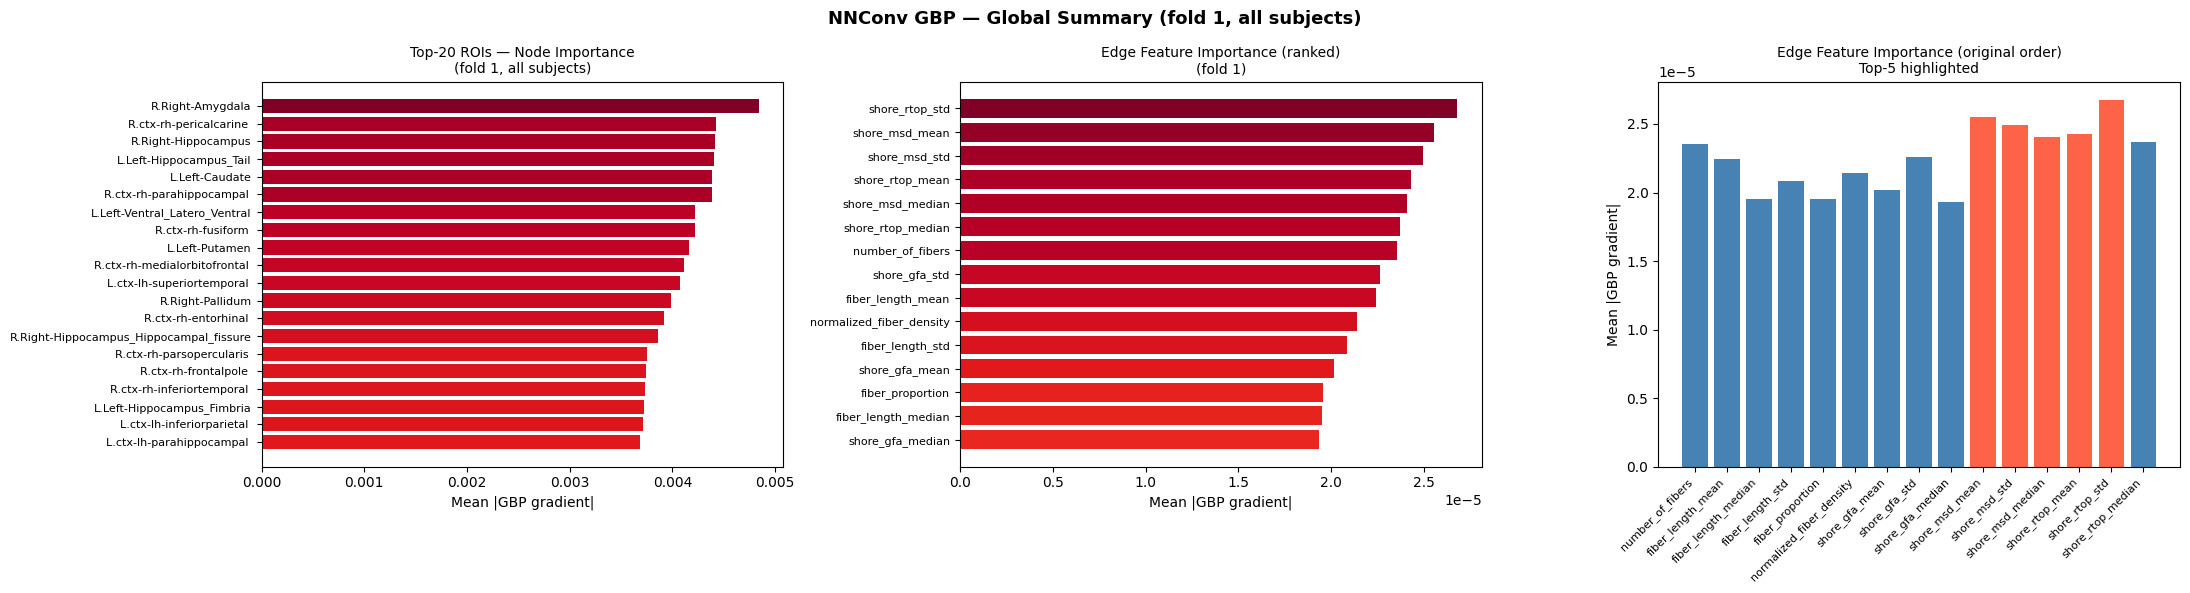

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

ax = axes[0]
show_idx   = top_nodes_global[:TOP_N]
show_vals  = avg_node_importance[show_idx]
bar_colors = plt.cm.YlOrRd(show_vals / show_vals.max())
ax.barh(range(TOP_N)[::-1], show_vals, color=bar_colors)
ax.set_yticks(range(TOP_N)[::-1])
ax.set_yticklabels([ROI_NAMES[i] for i in show_idx], fontsize=8)
ax.set_xlabel('Mean |GBP gradient|')
ax.set_title(f'Top-{TOP_N} ROIs — Node Importance\n(fold 1, all subjects)', fontsize=10)

ax = axes[1]
top_vals    = avg_edge_feat_global[ranked_feats]
top_labels  = [EDGE_FEAT_NAMES[i] for i in ranked_feats]
bar_colors2 = plt.cm.YlOrRd(top_vals / top_vals.max())
ax.barh(range(EDGE_IN)[::-1], top_vals, color=bar_colors2)
ax.set_yticks(range(EDGE_IN)[::-1])
ax.set_yticklabels(top_labels, fontsize=8)
ax.set_xlabel('Mean |GBP gradient|')
ax.set_title('Edge Feature Importance (ranked)\n(fold 1)', fontsize=10)

ax = axes[2]
feat_colors = ['tomato' if i in ranked_feats[:5] else 'steelblue' for i in range(EDGE_IN)]
ax.bar(range(EDGE_IN), avg_edge_feat_global, color=feat_colors)
ax.set_xticks(range(EDGE_IN))
ax.set_xticklabels(EDGE_FEAT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |GBP gradient|')
ax.set_title('Edge Feature Importance (original order)\nTop-5 highlighted', fontsize=10)

plt.suptitle('NNConv GBP — Global Summary (fold 1, all subjects)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_global_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

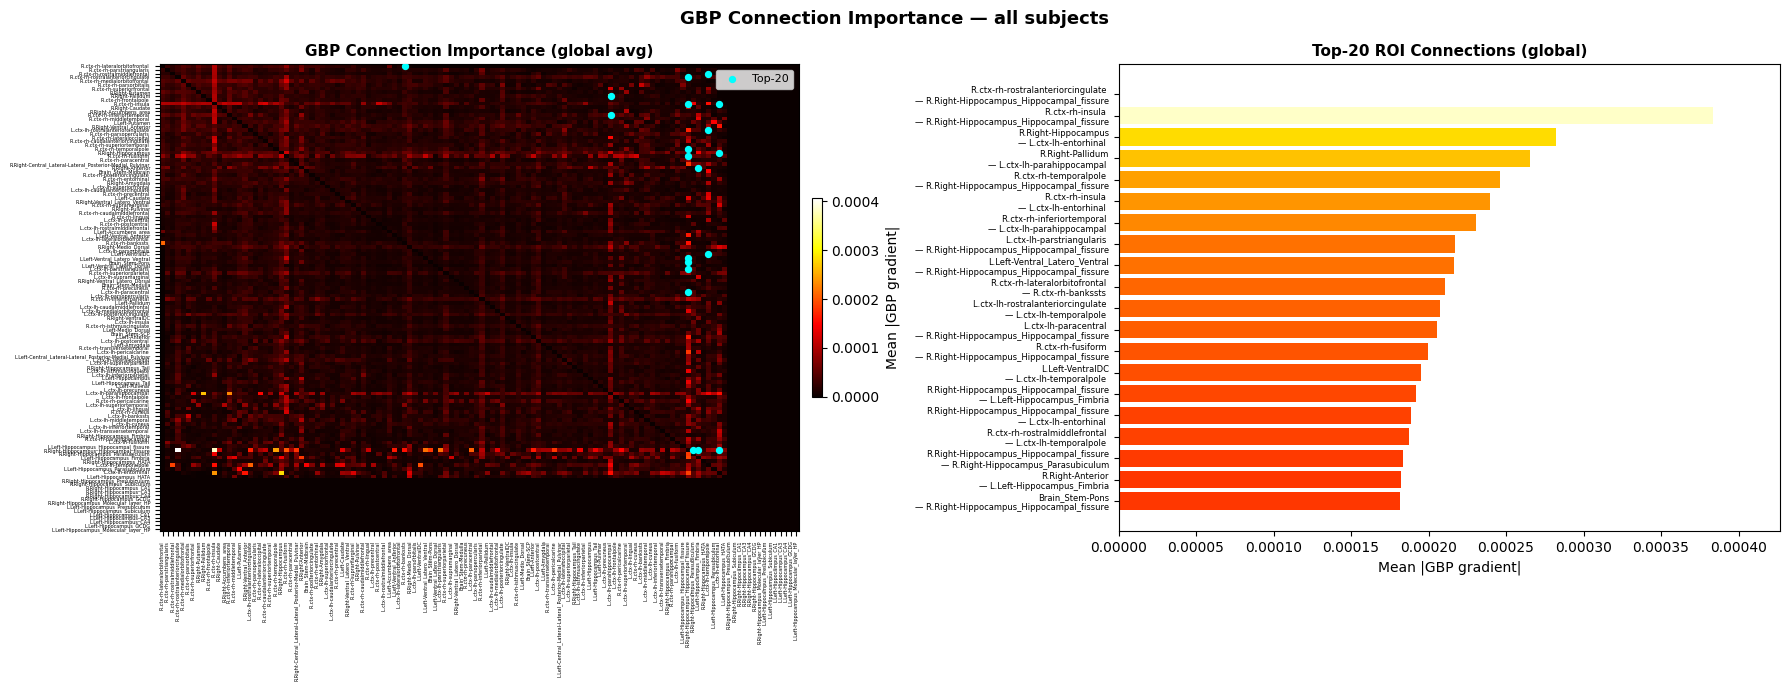

Top-20 connections (global):
   1. R.ctx-rh-rostralanteriorcingulate        — R.Right-Hippocampus_Hippocampal_fissure   0.000406
   2. R.ctx-rh-insula                          — R.Right-Hippocampus_Hippocampal_fissure   0.000384
   3. R.Right-Hippocampus                      — L.ctx-lh-entorhinal                       0.000282
   4. R.Right-Pallidum                         — L.ctx-lh-parahippocampal                  0.000265
   5. R.ctx-rh-temporalpole                    — R.Right-Hippocampus_Hippocampal_fissure   0.000246
   6. R.ctx-rh-insula                          — L.ctx-lh-entorhinal                       0.000239
   7. R.ctx-rh-inferiortemporal                — L.ctx-lh-parahippocampal                  0.000231
   8. L.ctx-lh-parstriangularis                — R.Right-Hippocampus_Hippocampal_fissure   0.000217
   9. L.Left-Ventral_Latero_Ventral            — R.Right-Hippocampus_Hippocampal_fissure   0.000216
  10. R.ctx-rh-lateralorbitofrontal            — R.ctx-rh-bankssts     

In [10]:
K = 20
mask_ut  = np.triu(avg_conn_global, k=1)
flat_idx = np.argsort(mask_ut.ravel())[::-1]
top_r, top_c = np.unravel_index(flat_idx[:K], (NUM_NODES, NUM_NODES))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
im = ax.imshow(avg_conn_global, cmap='hot', aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02, label='Mean |GBP gradient|')
ax.scatter(top_c, top_r, s=18, c='cyan', zorder=5, label=f'Top-{K}')
ax.set_title('GBP Connection Importance (global avg)', fontsize=11, fontweight='bold')
ax.set_xticks(range(NUM_NODES)); ax.set_xticklabels(ROI_NAMES, rotation=90, fontsize=3.5)
ax.set_yticks(range(NUM_NODES)); ax.set_yticklabels(ROI_NAMES, fontsize=3.5)
ax.legend(loc='upper right', fontsize=8)

ax = axes[1]
edge_labels = [f'{ROI_NAMES[r]}\n— {ROI_NAMES[c]}' for r, c in zip(top_r, top_c)]
edge_vals   = [avg_conn_global[r, c] for r, c in zip(top_r, top_c)]
bar_col     = plt.cm.hot(np.array(edge_vals) / max(edge_vals))
ax.barh(range(K)[::-1], edge_vals, color=bar_col)
ax.set_yticks(range(K)[::-1])
ax.set_yticklabels(edge_labels, fontsize=6)
ax.set_xlabel('Mean |GBP gradient|')
ax.set_title(f'Top-{K} ROI Connections (global)', fontsize=11, fontweight='bold')

plt.suptitle('GBP Connection Importance — all subjects', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_connection_global.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Top-{K} connections (global):')
for rank, (r, c) in enumerate(zip(top_r, top_c), 1):
    print(f'  {rank:2d}. {ROI_NAMES[r]:<40s} — {ROI_NAMES[c]:<40s}  {avg_conn_global[r, c]:.6f}')

### Section 2 — TP / TN / FP / FN Node Importance

Each panel shows the ROIs that most strongly drove *that specific* prediction outcome.
Using the predicted class as the attribution target makes these bars directly comparable
to what GradCAM and IG report.

- **TP**: what the model correctly relies on to detect MCI
- **TN**: what correctly suppresses MCI attribution in healthy subjects
- **FP**: what misleads the model into calling a CN subject MCI
- **FN**: what the model fails to pick up when it misses a real MCI case

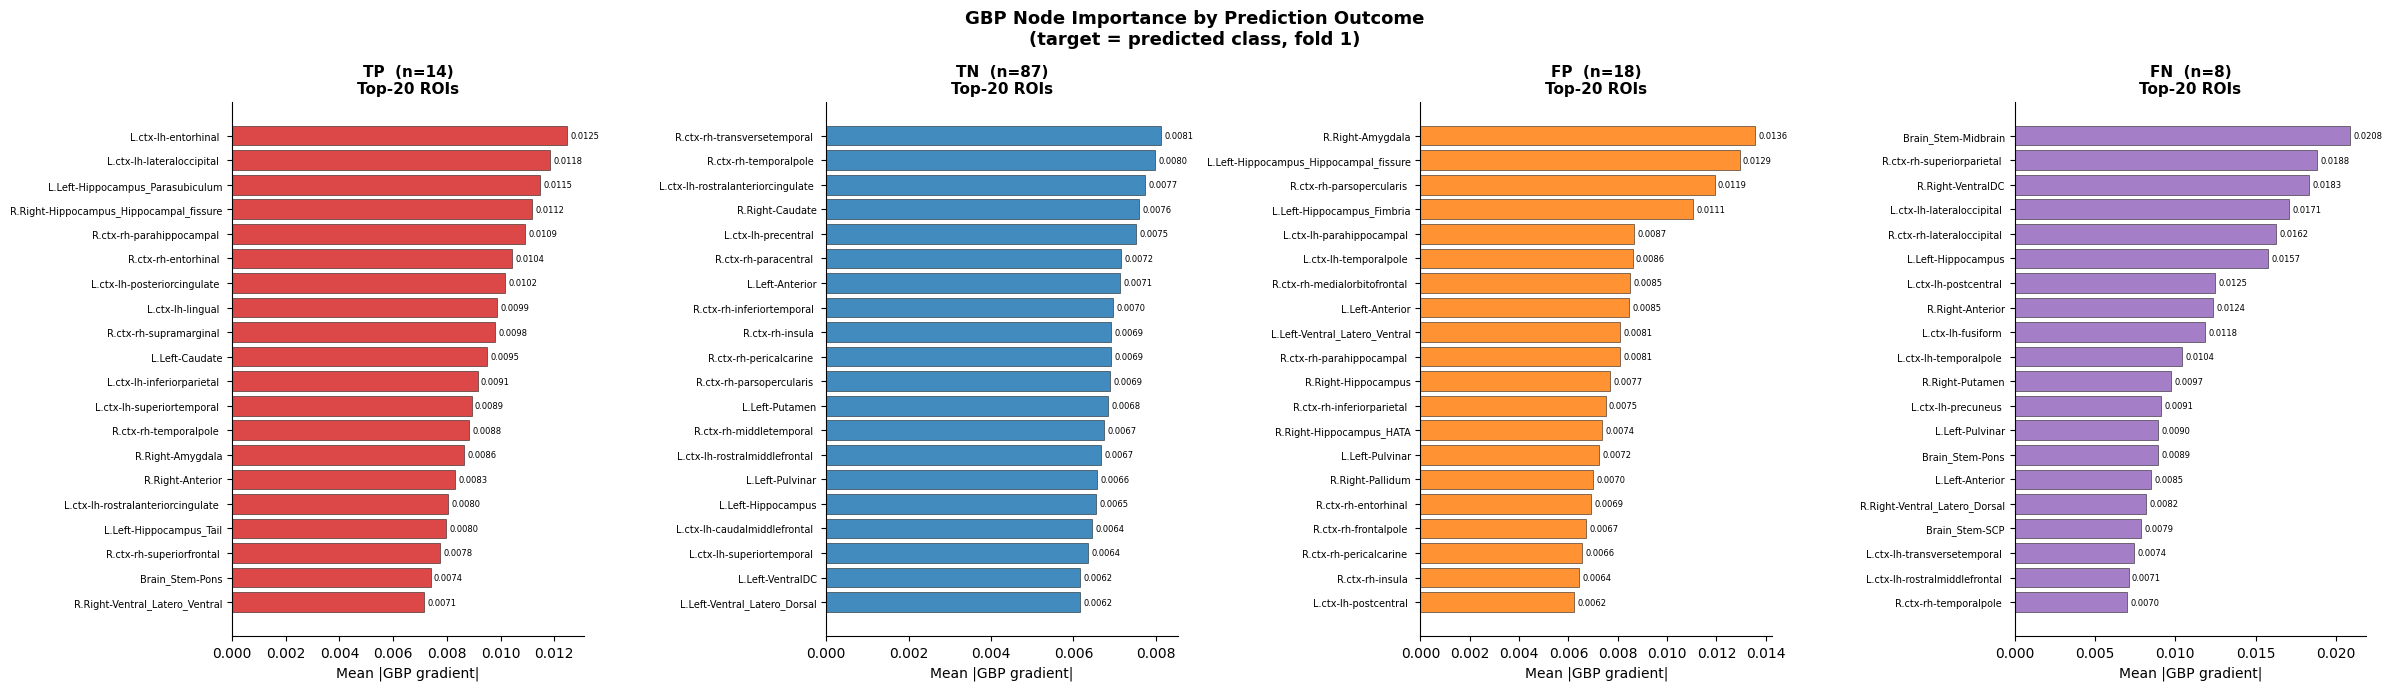


TP (n=14) — top-10 ROIs:
   1. L.ctx-lh-entorhinal                       0.012480
   2. L.ctx-lh-lateraloccipital                 0.011842
   3. L.Left-Hippocampus_Parasubiculum          0.011485
   4. R.Right-Hippocampus_Hippocampal_fissure   0.011175
   5. R.ctx-rh-parahippocampal                  0.010926
   6. R.ctx-rh-entorhinal                       0.010433
   7. L.ctx-lh-posteriorcingulate               0.010162
   8. L.ctx-lh-lingual                          0.009880
   9. R.ctx-rh-supramarginal                    0.009804
  10. L.Left-Caudate                            0.009496

TN (n=87) — top-10 ROIs:
   1. R.ctx-rh-transversetemporal               0.008133
   2. R.ctx-rh-temporalpole                     0.007979
   3. L.ctx-lh-rostralanteriorcingulate         0.007740
   4. R.Right-Caudate                           0.007584
   5. L.ctx-lh-precentral                       0.007510
   6. R.ctx-rh-paracentral                      0.007164
   7. L.Left-Anterior               

In [11]:
available = [t for t in OUTCOMES if o_node_abs_avg[t] is not None]

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 7))
if len(available) == 1:
    axes = [axes]

for ax, tag in zip(axes, available):
    avg   = o_node_abs_avg[tag]
    n     = o_count[tag]
    idxs  = np.argsort(avg)[::-1][:TOP_N]
    vals  = avg[idxs][::-1]
    names = [ROI_NAMES[i] for i in idxs][::-1]
    bars  = ax.barh(names, vals, color=OUTCOME_COLORS[tag], alpha=0.85,
                    edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Mean |GBP gradient|', fontsize=10)
    ax.set_title(f'{tag}  (n={n})\nTop-{TOP_N} ROIs', fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + vals.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', fontsize=6)

plt.suptitle('GBP Node Importance by Prediction Outcome\n'
             '(target = predicted class, fold 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_outcome_node_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

for tag in available:
    avg  = o_node_abs_avg[tag]
    idxs = np.argsort(avg)[::-1][:10]
    print(f'\n{tag} (n={o_count[tag]}) — top-10 ROIs:')
    for rank, i in enumerate(idxs, 1):
        print(f'  {rank:2d}. {ROI_NAMES[i]:<40s}  {avg[i]:.6f}')

### Section 3 — Signed Attributions per Outcome

The global analysis uses `abs()` and loses directional information. Here, the mean
signed gradient per node is shown instead:

- **Positive bar** → the ROI pushed the model *toward* the predicted class
- **Negative bar** → the ROI pulled *against* the prediction (suppressive signal)

This is the GBP equivalent of IG's signed attribution plot.

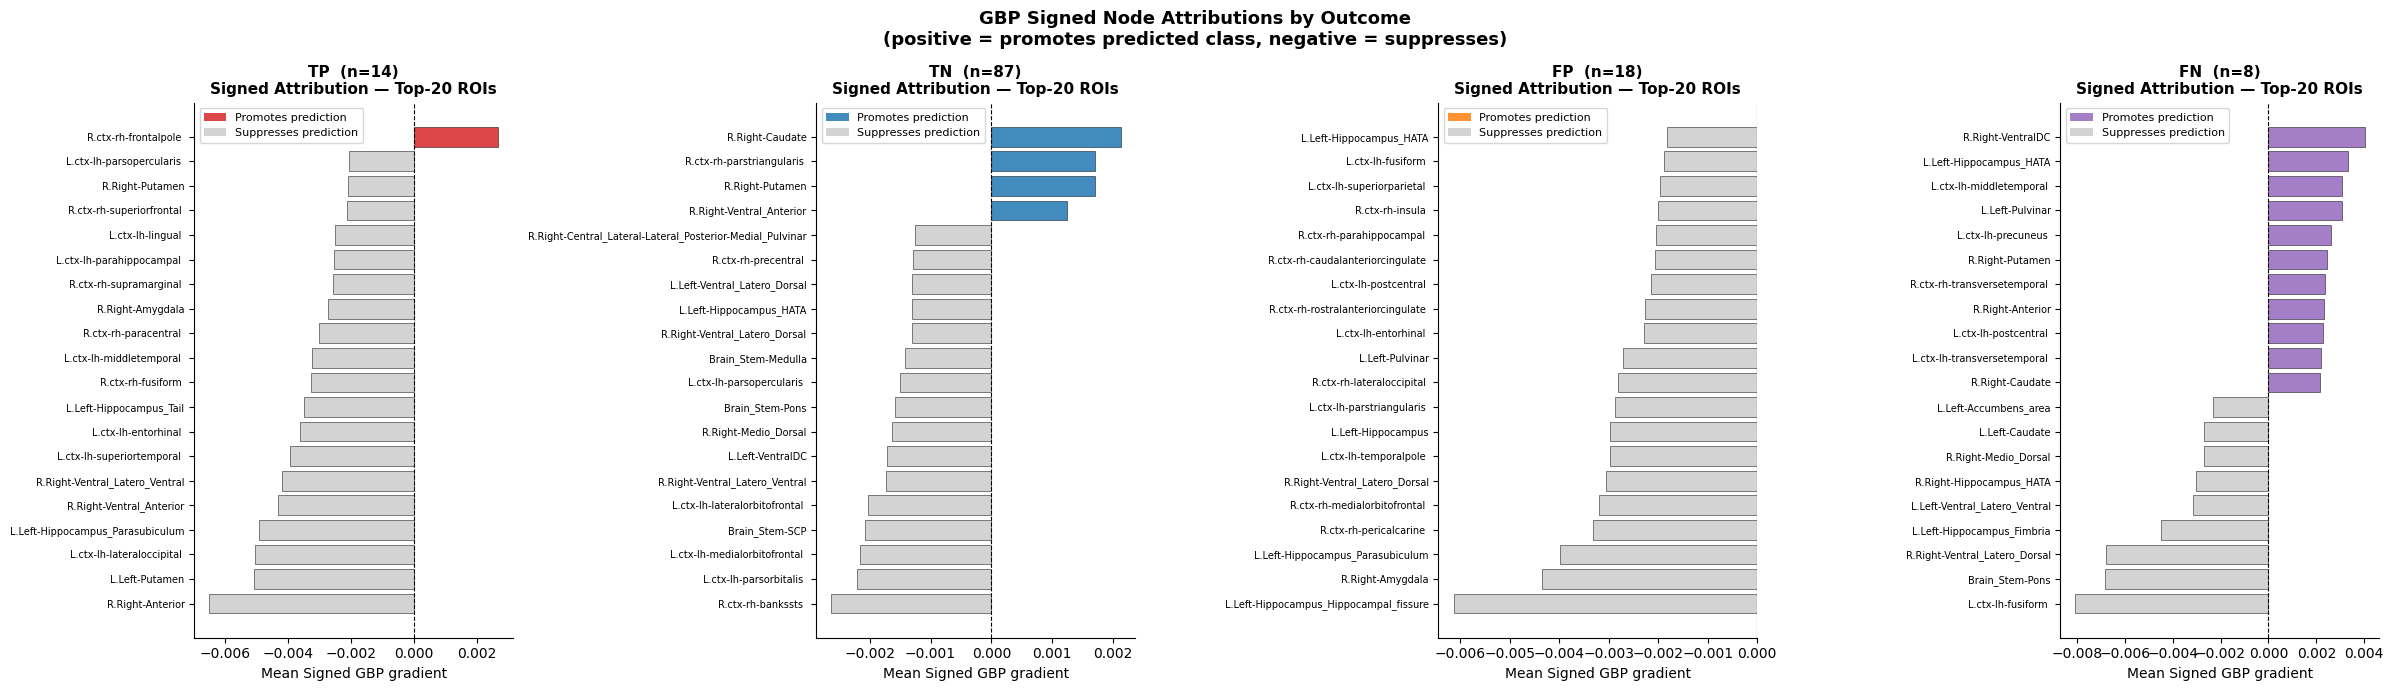

In [12]:
fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 7))
if len(available) == 1:
    axes = [axes]

for ax, tag in zip(axes, available):
    sgn_avg    = o_node_sgn_avg[tag]
    n          = o_count[tag]
    idxs       = np.argsort(np.abs(sgn_avg))[::-1][:TOP_N]
    top_sgn    = sgn_avg[idxs]
    top_names  = [ROI_NAMES[i] for i in idxs]
    sort_order = np.argsort(top_sgn)
    top_sgn    = top_sgn[sort_order]
    top_names  = [top_names[i] for i in sort_order]
    bar_colors = [OUTCOME_COLORS[tag] if s > 0 else '#cccccc' for s in top_sgn]
    ax.barh(top_names, top_sgn, color=bar_colors, alpha=0.85,
            edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean Signed GBP gradient', fontsize=10)
    ax.set_title(f'{tag}  (n={n})\nSigned Attribution — Top-{TOP_N} ROIs',
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)
    legend_elements = [
        Patch(facecolor=OUTCOME_COLORS[tag], alpha=0.85, label='Promotes prediction'),
        Patch(facecolor='#cccccc',           alpha=0.85, label='Suppresses prediction'),
    ]
    ax.legend(handles=legend_elements, fontsize=8)

plt.suptitle('GBP Signed Node Attributions by Outcome\n'
             '(positive = promotes predicted class, negative = suppresses)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_signed_attributions.png'), dpi=150, bbox_inches='tight')
plt.show()

### Section 5  — Connection Importance: TP vs FP (and TN vs FN)

The `(NUM_NODES × NUM_NODES)` connection matrices compared side-by-side reveal which
structural connectivity patterns mislead the model.

- **TP vs FP**: FP subjects are CN but called MCI. Connections that appear in *both* TP and FP
  top-K lists indicate connectivity patterns that genuinely resemble MCI-like structure but are not.
- **TN vs FN**: FN subjects are MCI but missed. Connections that appear in TN but not FN reveal
  what the model normally uses to recognise health — absent or weaker in missed MCI cases.

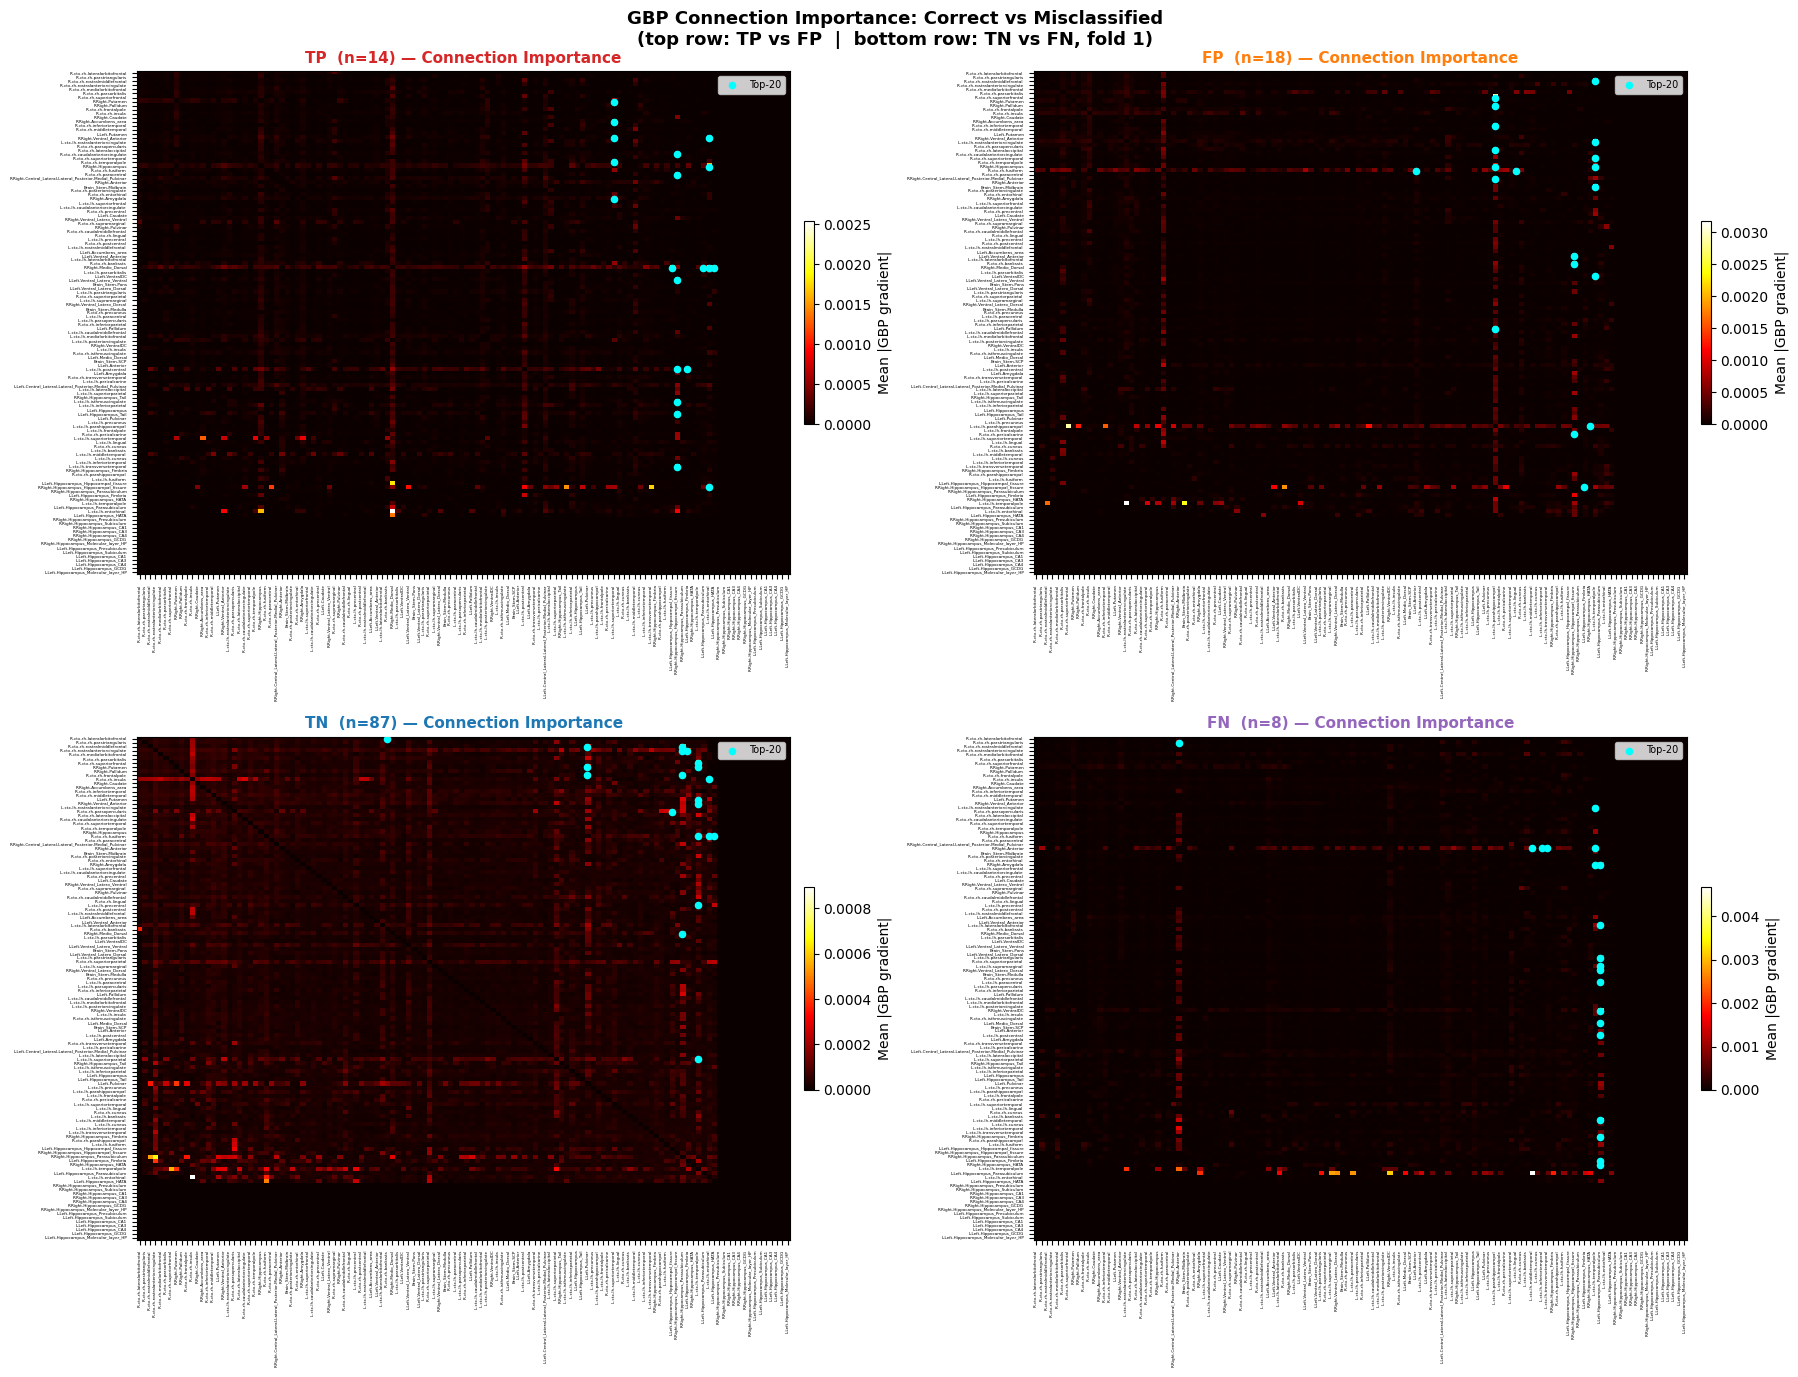

In [13]:
K_conn = 20

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
compare_pairs = [('TP', 'FP'), ('TN', 'FN')]

for row, (tag_a, tag_b) in enumerate(compare_pairs):
    for col, tag in enumerate([tag_a, tag_b]):
        ax = axes[row][col]
        if o_conn_avg[tag] is None:
            ax.set_visible(False)
            continue
        mat    = o_conn_avg[tag]
        n      = o_count[tag]
        mask   = np.triu(mat, k=1)
        f_idx  = np.argsort(mask.ravel())[::-1]
        tr, tc = np.unravel_index(f_idx[:K_conn], (NUM_NODES, NUM_NODES))
        im     = ax.imshow(mat, cmap='hot', aspect='auto')
        plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02, label='Mean |GBP gradient|')
        ax.scatter(tc, tr, s=20, c='cyan', zorder=5, label=f'Top-{K_conn}')
        ax.set_title(f'{tag}  (n={n}) — Connection Importance',
                     fontsize=11, fontweight='bold', color=OUTCOME_COLORS[tag])
        ax.set_xticks(range(NUM_NODES)); ax.set_xticklabels(ROI_NAMES, rotation=90, fontsize=3)
        ax.set_yticks(range(NUM_NODES)); ax.set_yticklabels(ROI_NAMES, fontsize=3)
        ax.legend(loc='upper right', fontsize=7)

plt.suptitle('GBP Connection Importance: Correct vs Misclassified\n'
             '(top row: TP vs FP  |  bottom row: TN vs FN, fold 1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_connection_outcome_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

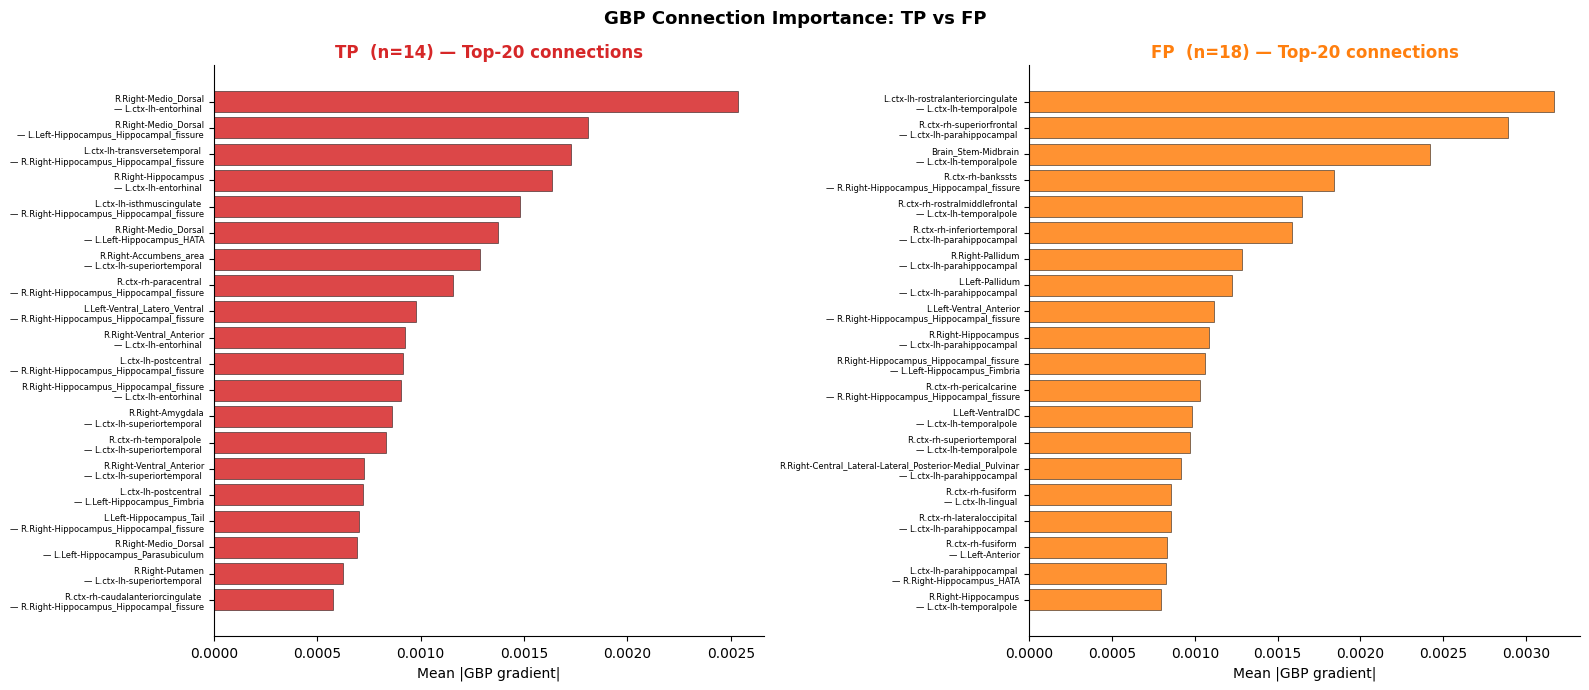


TP/FP shared top-20 connections (0 overlap):


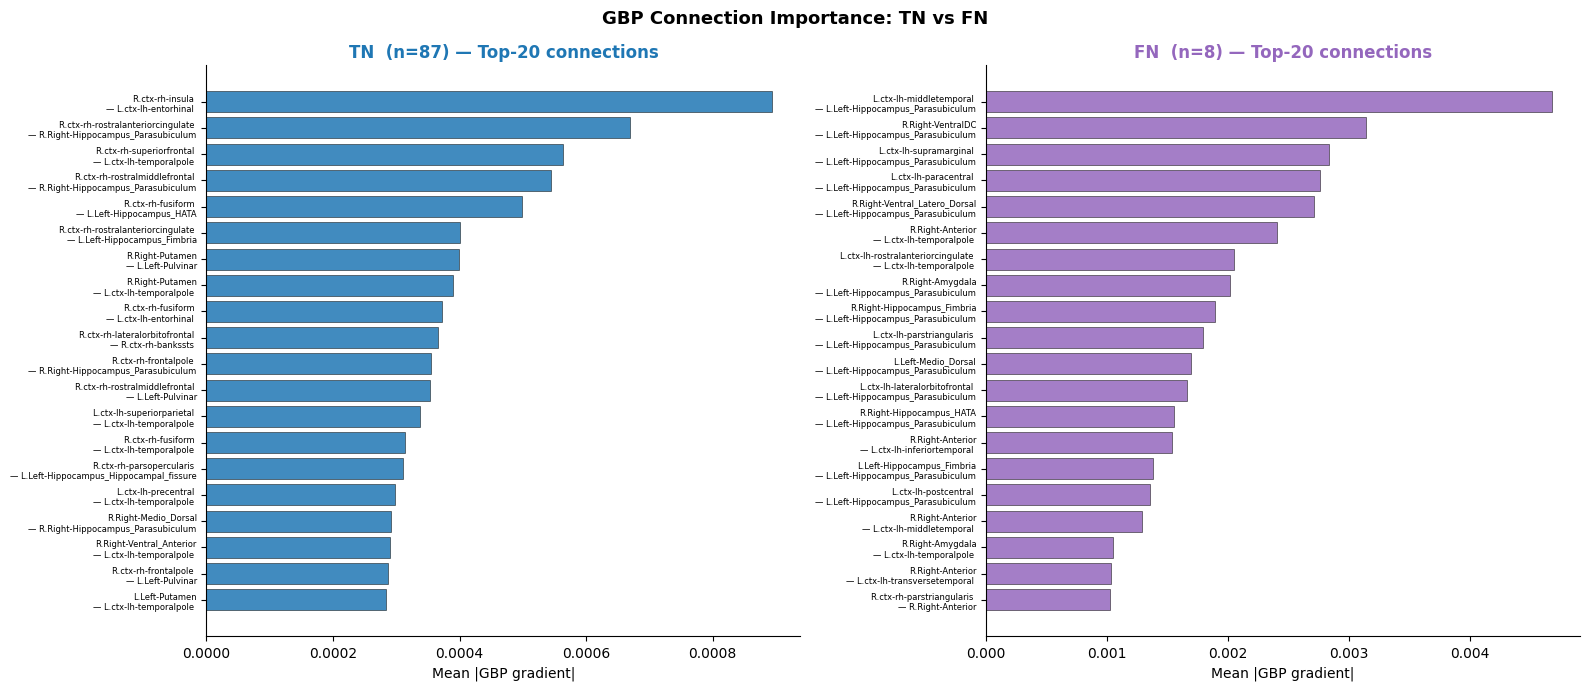


TN/FN shared top-20 connections (0 overlap):


In [14]:
# Ranked bar charts and overlap analysis for each pair
def top_k_set(mat, k):
    mask = np.triu(mat, k=1)
    f    = np.argsort(mask.ravel())[::-1]
    r, c = np.unravel_index(f[:k], (NUM_NODES, NUM_NODES))
    return set(zip(r.tolist(), c.tolist()))

for tag_a, tag_b in [('TP', 'FP'), ('TN', 'FN')]:
    if o_conn_avg[tag_a] is None or o_conn_avg[tag_b] is None:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, tag in zip(axes, [tag_a, tag_b]):
        mat    = o_conn_avg[tag]
        n      = o_count[tag]
        mask   = np.triu(mat, k=1)
        f_idx  = np.argsort(mask.ravel())[::-1]
        tr, tc = np.unravel_index(f_idx[:K_conn], (NUM_NODES, NUM_NODES))
        labels = [f'{ROI_NAMES[r]}\n— {ROI_NAMES[c]}' for r, c in zip(tr, tc)]
        vals   = [mat[r, c] for r, c in zip(tr, tc)]
        ax.barh(range(K_conn)[::-1], vals, color=OUTCOME_COLORS[tag],
                alpha=0.85, edgecolor='black', linewidth=0.4)
        ax.set_yticks(range(K_conn)[::-1])
        ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel('Mean |GBP gradient|')
        ax.set_title(f'{tag}  (n={n}) — Top-{K_conn} connections',
                     fontsize=12, fontweight='bold', color=OUTCOME_COLORS[tag])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.suptitle(f'GBP Connection Importance: {tag_a} vs {tag_b}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'gbp_connection_{tag_a}_vs_{tag_b}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    # Overlap
    set_a  = top_k_set(o_conn_avg[tag_a], K_conn)
    set_b  = top_k_set(o_conn_avg[tag_b], K_conn)
    shared = set_a & set_b
    print(f'\n{tag_a}/{tag_b} shared top-{K_conn} connections ({len(shared)} overlap):')
    for r, c in sorted(shared):
        print(f'  {ROI_NAMES[r]:<40s} — {ROI_NAMES[c]:<40s}  '
              f'{tag_a}={o_conn_avg[tag_a][r,c]:.6f}  {tag_b}={o_conn_avg[tag_b][r,c]:.6f}')

### Section 6 — Per-Outcome Edge Feature Importance

Which of the 15 dMRI tractography features matter for each prediction outcome?
- **Grouped bar chart**: raw scores per outcome per feature
- **Normalised heatmap**: each row scaled to its own max for pattern comparison

If a feature (e.g. `shore_gfa_mean`) drives both TP and FP equally, it is useful for
identifying MCI-like patterns but not specific enough. Features that are high in TP
but low in FP are the most discriminative tractography signals.

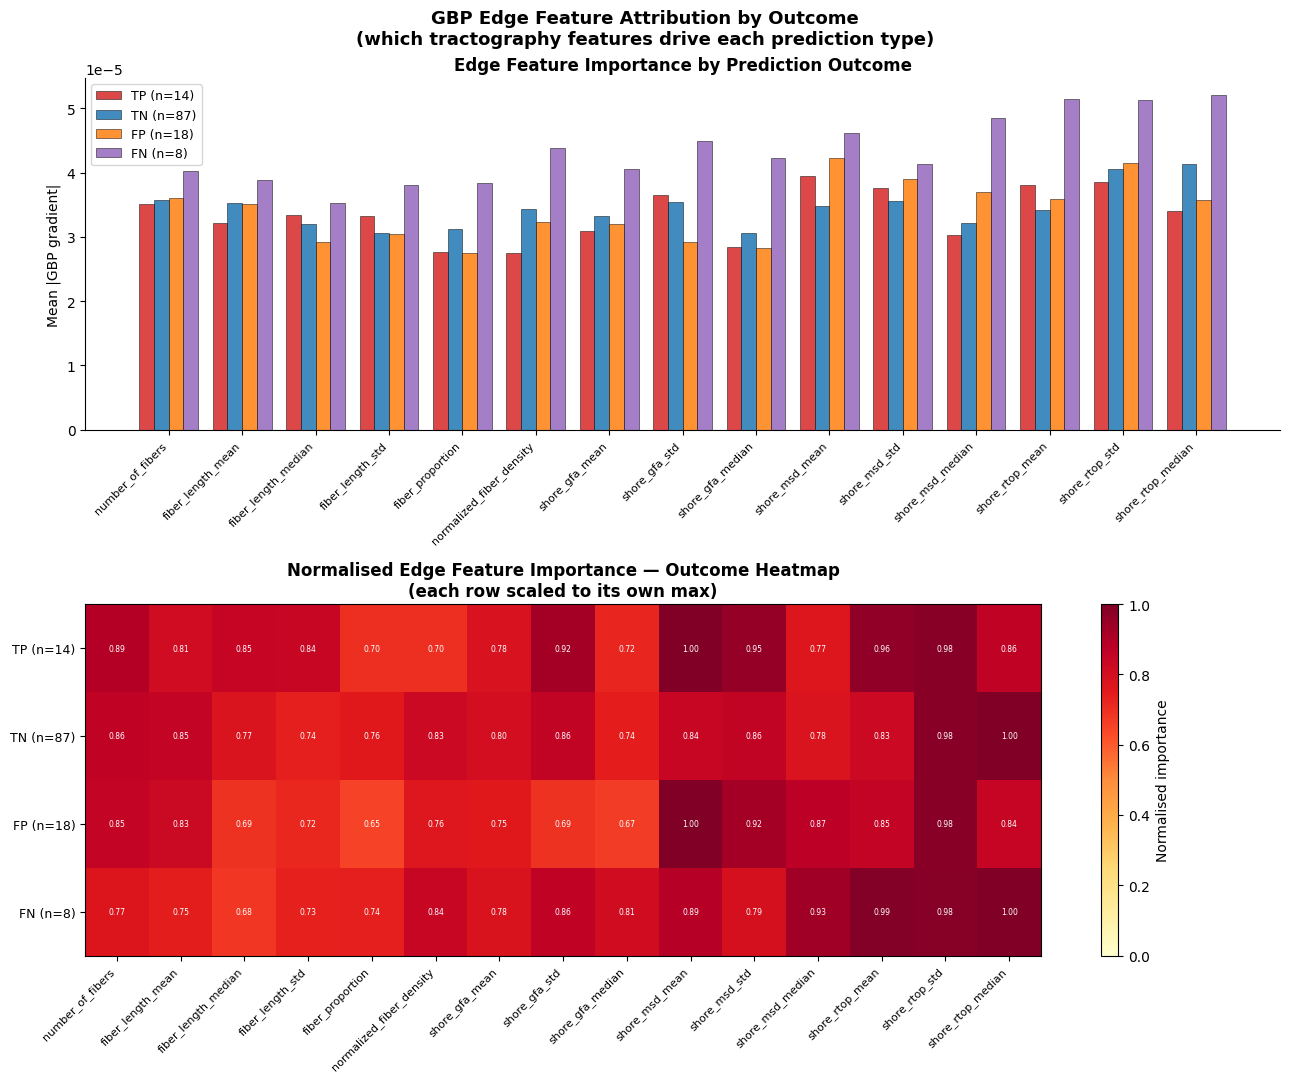

Edge feature ranking per outcome:

  TP (n=14):
    1. shore_msd_mean                  0.000039
    2. shore_rtop_std                  0.000039
    3. shore_rtop_mean                 0.000038
    4. shore_msd_std                   0.000038
    5. shore_gfa_std                   0.000036

  TN (n=87):
    1. shore_rtop_median               0.000041
    2. shore_rtop_std                  0.000041
    3. number_of_fibers                0.000036
    4. shore_msd_std                   0.000036
    5. shore_gfa_std                   0.000035

  FP (n=18):
    1. shore_msd_mean                  0.000042
    2. shore_rtop_std                  0.000041
    3. shore_msd_std                   0.000039
    4. shore_msd_median                0.000037
    5. number_of_fibers                0.000036

  FN (n=8):
    1. shore_rtop_median               0.000052
    2. shore_rtop_mean                 0.000052
    3. shore_rtop_std                  0.000051
    4. shore_msd_median                0.000049

In [15]:
available_feat = [t for t in OUTCOMES if o_edge_feat_avg[t] is not None]

fig, axes = plt.subplots(2, 1, figsize=(13, 11))

ax = axes[0]
x     = np.arange(EDGE_IN)
width = 0.8 / len(available_feat)
for i, tag in enumerate(available_feat):
    offset = (i - len(available_feat) / 2 + 0.5) * width
    n      = o_count[tag]
    ax.bar(x + offset, o_edge_feat_avg[tag], width,
           label=f'{tag} (n={n})', color=OUTCOME_COLORS[tag],
           alpha=0.85, edgecolor='black', linewidth=0.4)
ax.set_xticks(x)
ax.set_xticklabels(EDGE_FEAT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean |GBP gradient|', fontsize=10)
ax.set_title('Edge Feature Importance by Prediction Outcome', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax = axes[1]
feat_matrix = np.stack([o_edge_feat_avg[t] for t in available_feat], axis=0)
norm_matrix = feat_matrix / feat_matrix.max(axis=1, keepdims=True)
im = ax.imshow(norm_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Normalised importance')
ax.set_xticks(range(EDGE_IN))
ax.set_xticklabels(EDGE_FEAT_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(available_feat)))
ax.set_yticklabels([f'{t} (n={o_count[t]})' for t in available_feat], fontsize=9)
ax.set_title('Normalised Edge Feature Importance — Outcome Heatmap\n'
             '(each row scaled to its own max)', fontsize=12, fontweight='bold')
for oi in range(len(available_feat)):
    for fi in range(EDGE_IN):
        ax.text(fi, oi, f'{norm_matrix[oi, fi]:.2f}',
                ha='center', va='center', fontsize=5.5,
                color='white' if norm_matrix[oi, fi] > 0.6 else 'black')

plt.suptitle('GBP Edge Feature Attribution by Outcome\n'
             '(which tractography features drive each prediction type)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_edge_feature_by_outcome.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Edge feature ranking per outcome:')
for tag in available_feat:
    ranked = np.argsort(o_edge_feat_avg[tag])[::-1]
    print(f'\n  {tag} (n={o_count[tag]}):')
    for rank, i in enumerate(ranked[:5], 1):
        print(f'    {rank}. {EDGE_FEAT_NAMES[i]:<30s}  {o_edge_feat_avg[tag][i]:.6f}')

### Section 7 — TP vs TN: What the Model Correctly Relies On

The clearest clinical summary: what distinguishes correct MCI detection from correct CN identification.

- ROIs in **both** lists are non-discriminative (the model uses them regardless of class)
- ROIs in **TP only** are genuinely MCI-specific structural signals
- ROIs in **TN only** are CN-specific (healthy brain structure the model recognises correctly)

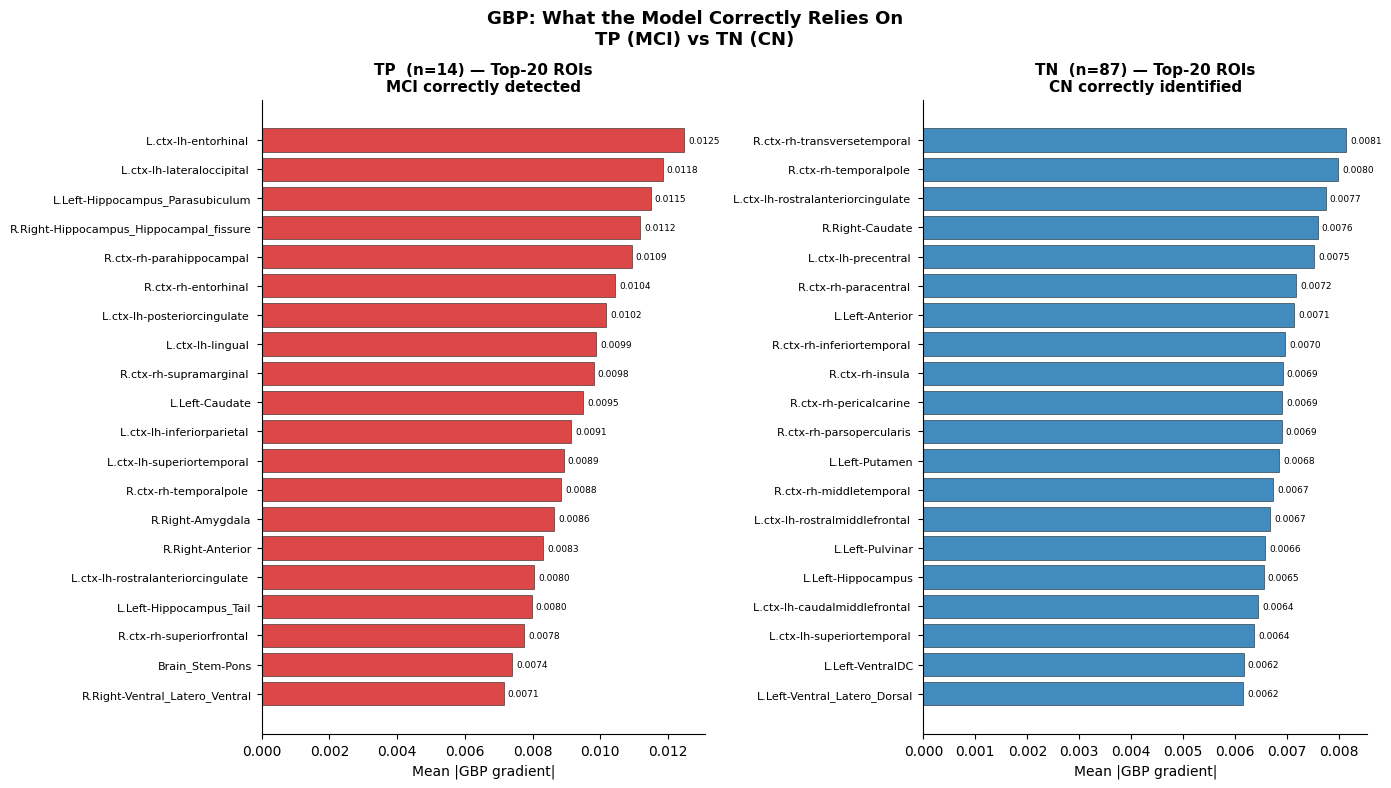

TP/TN top-20 overlap: 3 shared, 17 TP-only, 17 TN-only

MCI-specific ROIs (TP only):
  L.ctx-lh-entorhinal                            TP=0.012480
  L.ctx-lh-lateraloccipital                      TP=0.011842
  L.Left-Hippocampus_Parasubiculum               TP=0.011485
  R.Right-Hippocampus_Hippocampal_fissure        TP=0.011175
  R.ctx-rh-parahippocampal                       TP=0.010926
  R.ctx-rh-entorhinal                            TP=0.010433
  L.ctx-lh-posteriorcingulate                    TP=0.010162
  L.ctx-lh-lingual                               TP=0.009880
  R.ctx-rh-supramarginal                         TP=0.009804
  L.Left-Caudate                                 TP=0.009496
  L.ctx-lh-inferiorparietal                      TP=0.009142
  R.Right-Amygdala                               TP=0.008637
  R.Right-Anterior                               TP=0.008309
  L.Left-Hippocampus_Tail                        TP=0.007970
  R.ctx-rh-superiorfrontal                       TP=0.007755


In [16]:
if o_node_abs_avg['TP'] is not None and o_node_abs_avg['TN'] is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    for ax, tag in zip(axes, ['TP', 'TN']):
        avg   = o_node_abs_avg[tag]
        n     = o_count[tag]
        idxs  = np.argsort(avg)[::-1][:TOP_N]
        vals  = avg[idxs][::-1]
        names = [ROI_NAMES[i] for i in idxs][::-1]
        bars  = ax.barh(names, vals, color=OUTCOME_COLORS[tag], alpha=0.85,
                        edgecolor='black', linewidth=0.4)
        ax.set_xlabel('Mean |GBP gradient|', fontsize=10)
        label = 'MCI correctly detected' if tag == 'TP' else 'CN correctly identified'
        ax.set_title(f'{tag}  (n={n}) — Top-{TOP_N} ROIs\n{label}',
                     fontsize=11, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width() + vals.max() * 0.01,
                    bar.get_y() + bar.get_height() / 2,
                    f'{v:.4f}', va='center', fontsize=6.5)

    plt.suptitle('GBP: What the Model Correctly Relies On\nTP (MCI) vs TN (CN)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_tp_vs_tn_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

    tp_set_nodes = set(np.argsort(o_node_abs_avg['TP'])[::-1][:TOP_N])
    tn_set_nodes = set(np.argsort(o_node_abs_avg['TN'])[::-1][:TOP_N])
    shared_nodes = tp_set_nodes & tn_set_nodes
    tp_only      = tp_set_nodes - tn_set_nodes
    tn_only      = tn_set_nodes - tp_set_nodes

    print(f'TP/TN top-{TOP_N} overlap: {len(shared_nodes)} shared, '
          f'{len(tp_only)} TP-only, {len(tn_only)} TN-only')

    if tp_only:
        print('\nMCI-specific ROIs (TP only):')
        for i in sorted(tp_only, key=lambda x: -o_node_abs_avg['TP'][x]):
            print(f'  {ROI_NAMES[i]:<45s}  TP={o_node_abs_avg["TP"][i]:.6f}')

    if tn_only:
        print('\nCN-specific ROIs (TN only):')
        for i in sorted(tn_only, key=lambda x: -o_node_abs_avg['TN'][x]):
            print(f'  {ROI_NAMES[i]:<45s}  TN={o_node_abs_avg["TN"][i]:.6f}')

print('\nAll figures saved to:', OUTPUT_DIR)

---
## What does "MCI target" mean in gradient-based explanations?

When we compute GBP (or SmoothGrad, IG) with `target_class = 1 (MCI)`, we backpropagate from the **raw MCI logit** — the model's un-normalised score for predicting MCI — back through the network to the input features.

The resulting gradient at each input feature answers:
> *"If I slightly increased this feature value, would the MCI score go up or down?"*

- **Positive gradient** → higher feature value → higher MCI score → this ROI/feature **pushes the model toward predicting MCI**
- **Negative gradient** → higher feature value → lower MCI score → this ROI/feature **pushes the model toward predicting CN**

So *"top 20 ROIs with MCI target"* = the 20 ROIs whose input features have the largest gradient magnitude w.r.t. the MCI logit. Changing them even slightly would maximally shift the model's MCI confidence. GBP additionally zeroes out gradients that flow through inactive ReLUs and any negative gradients, so it highlights only the **positive evidence** for the MCI prediction.

**Important distinction from "predicted class target":**
- `target = MCI` always: makes CN and MCI subjects comparable on the *same axis* (how much does each ROI support MCI?). Used for signed/directional plots.
- `target = predicted class`: explains *what drove this specific prediction*, regardless of direction. Used for magnitude/ranking within each outcome group (TP/TN/FP/FN).


### Section 8 — Per-class Data Collection (true MCI vs true CN)

Previous sections split subjects by **prediction outcome** (TP/TN/FP/FN).
This section splits by **true diagnosis label** (CN=0, MCI=1) to answer:

- Which ROIs are most important *across all true MCI subjects* (correctly and incorrectly classified)?
- Which ROIs are most important *across all true CN subjects*?
- What are the top-20 structural **connections** that distinguish real MCI from real CN brains?
- For each top ROI, does a **larger or smaller** value (volume, thickness) push the model toward MCI?

Two attribution modes are collected:
- `target=1 (MCI)` always → signed gradients, directly comparable across both classes
- `target=predicted` → absolute magnitude for each subject's actual prediction

In [17]:
CLASS_NAMES  = {0: 'CN', 1: 'MCI'}
CLASS_COLORS = {0: '#1f77b4', 1: '#d62728'}   # CN: blue, MCI: red

# Split test graphs by TRUE label
class_pools = {0: [], 1: []}
for graph in test_graphs:
    class_pools[graph.y.item()].append(graph)

print(f'CN  (true=0): {len(class_pools[0])} subjects')
print(f'MCI (true=1): {len(class_pools[1])} subjects')

# Per-class accumulators
#   _abs_mci   : |grad| w.r.t. MCI logit (for magnitude ranking on same axis)
#   _sgn_mci   : signed grad w.r.t. MCI logit (for directionality)
#   _feat_sgn  : signed grad per (node, feature) w.r.t. MCI logit
#   _conn      : per-edge |grad| w.r.t. MCI logit, accumulated into NxN matrix

cls_node_abs_sum  = {c: np.zeros(NUM_NODES,               dtype=np.float64) for c in [0, 1]}
cls_node_sgn_sum  = {c: np.zeros(NUM_NODES,               dtype=np.float64) for c in [0, 1]}
cls_feat_sgn_sum  = {c: np.zeros((NUM_NODES, NODE_IN),    dtype=np.float64) for c in [0, 1]}
cls_conn_sum      = {c: np.zeros((NUM_NODES, NUM_NODES),  dtype=np.float64) for c in [0, 1]}
cls_conn_count    = {c: np.zeros((NUM_NODES, NUM_NODES),  dtype=np.int64)   for c in [0, 1]}
cls_count         = {c: 0 for c in [0, 1]}

# Re-register GBP hooks (removed at end of earlier collection loop)
gbp = GuidedBackprop(model)

for cls_idx, pool in class_pools.items():
    for graph in pool:
        if graph.num_nodes != NUM_NODES:
            continue
        g = graph.to(device)

        # Signed node gradient w.r.t. MCI logit
        node_grad_mci = gbp.attribute(g, mode='node', target_class=1)   # (N, 4)
        node_abs_mci  = node_grad_mci.abs().mean(dim=1).cpu().numpy()   # (N,)
        node_sgn_mci  = node_grad_mci.mean(dim=1).cpu().numpy()         # (N,)
        feat_sgn_mci  = node_grad_mci.cpu().numpy()                     # (N, 4)

        cls_node_abs_sum[cls_idx] += node_abs_mci
        cls_node_sgn_sum[cls_idx] += node_sgn_mci
        cls_feat_sgn_sum[cls_idx] += feat_sgn_mci

        # Edge gradient w.r.t. MCI logit → connection matrix
        edge_grad_mci = gbp.attribute(g, mode='edge', target_class=1)
        per_edge_abs  = edge_grad_mci.abs().mean(dim=1).cpu().numpy()
        srcs = graph.edge_index[0].cpu().numpy()
        dsts = graph.edge_index[1].cpu().numpy()
        np.add.at(cls_conn_sum[cls_idx],   (srcs, dsts), per_edge_abs)
        np.add.at(cls_conn_count[cls_idx], (srcs, dsts), 1)

        cls_count[cls_idx] += 1

    print(f'{CLASS_NAMES[cls_idx]} (n={cls_count[cls_idx]}): done')

gbp.remove_hooks()

# Average and symmetrise
cls_node_abs_avg = {c: cls_node_abs_sum[c] / cls_count[c]  for c in [0, 1]}
cls_node_sgn_avg = {c: cls_node_sgn_sum[c] / cls_count[c]  for c in [0, 1]}
cls_feat_sgn_avg = {c: cls_feat_sgn_sum[c] / cls_count[c]  for c in [0, 1]}   # (N, 4)

cls_conn_avg = {}
for c in [0, 1]:
    with np.errstate(invalid='ignore'):
        mat = np.where(cls_conn_count[c] > 0,
                       cls_conn_sum[c] / cls_conn_count[c], 0.0)
    mat = 0.5 * (mat + mat.T)
    np.fill_diagonal(mat, 0)
    cls_conn_avg[c] = mat

print('Per-class GBP averaging done.')
print(f'  cls_node_abs_avg shape : {cls_node_abs_avg[0].shape}')
print(f'  cls_feat_sgn_avg shape : {cls_feat_sgn_avg[0].shape}')
print(f'  cls_conn_avg shape     : {cls_conn_avg[0].shape}')


CN  (true=0): 105 subjects
MCI (true=1): 22 subjects
CN (n=105): done
MCI (n=22): done
Per-class GBP averaging done.
  cls_node_abs_avg shape : (124,)
  cls_feat_sgn_avg shape : (124, 4)
  cls_conn_avg shape     : (124, 124)


### Section 9 — Top-20 ROIs: MCI vs CN (true label split)

Bar charts show the top-20 ROIs by mean `|GBP gradient|` w.r.t. the MCI logit,
averaged over all subjects with that true diagnosis. Both panels use the same
MCI target so the magnitudes are directly comparable across classes.

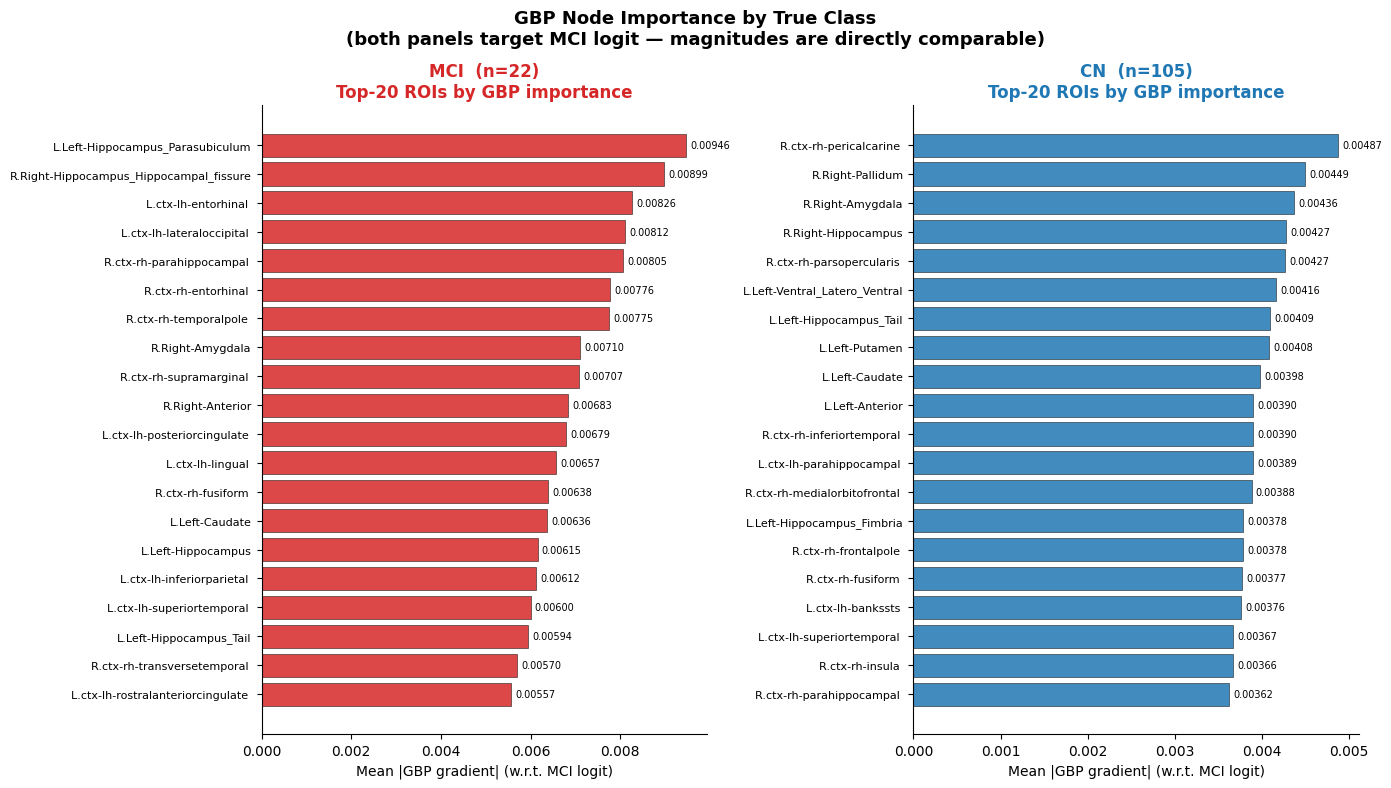

Top-20 overlap: 6 ROIs shared, 14 MCI-only, 14 CN-only

ROIs important exclusively in MCI subjects:
  L.Left-Hippocampus_Parasubiculum               MCI=0.009465  CN=0.001917
  R.Right-Hippocampus_Hippocampal_fissure        MCI=0.008985  CN=0.002783
  L.ctx-lh-entorhinal                            MCI=0.008264  CN=0.002238
  L.ctx-lh-lateraloccipital                      MCI=0.008116  CN=0.002552
  R.ctx-rh-entorhinal                            MCI=0.007764  CN=0.003108
  R.ctx-rh-temporalpole                          MCI=0.007749  CN=0.002670
  R.ctx-rh-supramarginal                         MCI=0.007075  CN=0.002089
  R.Right-Anterior                               MCI=0.006835  CN=0.002979
  L.ctx-lh-posteriorcingulate                    MCI=0.006786  CN=0.002554
  L.ctx-lh-lingual                               MCI=0.006574  CN=0.002244
  L.Left-Hippocampus                             MCI=0.006154  CN=0.002387
  L.ctx-lh-inferiorparietal                      MCI=0.006119  CN=0.003204


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, cls_idx in zip(axes, [1, 0]):   # MCI first, then CN
    cls_name  = CLASS_NAMES[cls_idx]
    color     = CLASS_COLORS[cls_idx]
    avg       = cls_node_abs_avg[cls_idx]
    n         = cls_count[cls_idx]

    idxs  = np.argsort(avg)[::-1][:TOP_N]
    vals  = avg[idxs][::-1]
    names = [ROI_NAMES[i] for i in idxs][::-1]

    bars = ax.barh(names, vals, color=color, alpha=0.85,
                   edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Mean |GBP gradient| (w.r.t. MCI logit)', fontsize=10)
    ax.set_title(f'{cls_name}  (n={n})\nTop-{TOP_N} ROIs by GBP importance',
                 fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + vals.max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{v:.5f}', va='center', fontsize=7)

plt.suptitle('GBP Node Importance by True Class\n'
             '(both panels target MCI logit — magnitudes are directly comparable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_class_node_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Textual overlap analysis
mci_top = set(np.argsort(cls_node_abs_avg[1])[::-1][:TOP_N])
cn_top  = set(np.argsort(cls_node_abs_avg[0])[::-1][:TOP_N])
shared  = mci_top & cn_top

print(f'Top-{TOP_N} overlap: {len(shared)} ROIs shared, '
      f'{len(mci_top - cn_top)} MCI-only, {len(cn_top - mci_top)} CN-only\n')

if mci_top - cn_top:
    print('ROIs important exclusively in MCI subjects:')
    for i in sorted(mci_top - cn_top, key=lambda x: -cls_node_abs_avg[1][x]):
        print(f'  {ROI_NAMES[i]:<45s}  MCI={cls_node_abs_avg[1][i]:.6f}  CN={cls_node_abs_avg[0][i]:.6f}')

if cn_top - mci_top:
    print('\nROIs important exclusively in CN subjects:')
    for i in sorted(cn_top - mci_top, key=lambda x: -cls_node_abs_avg[0][x]):
        print(f'  {ROI_NAMES[i]:<45s}  CN={cls_node_abs_avg[0][i]:.6f}  MCI={cls_node_abs_avg[1][i]:.6f}')


### Section 10 — Signed GBP Attribution w.r.t. MCI: MCI vs CN subjects

Signed gradients (averaged over features per node, then over subjects) answer:
> *"For each ROI, does its activity on average push the model toward MCI or toward CN?"*

- **Red bar (positive)** → ROI pushes toward MCI prediction
- **Blue bar (negative)** → ROI pushes toward CN prediction

The difference panel (MCI subjects − CN subjects) highlights which ROIs are
*differentially* important between the two populations — these are the most
class-discriminative brain regions according to GBP.

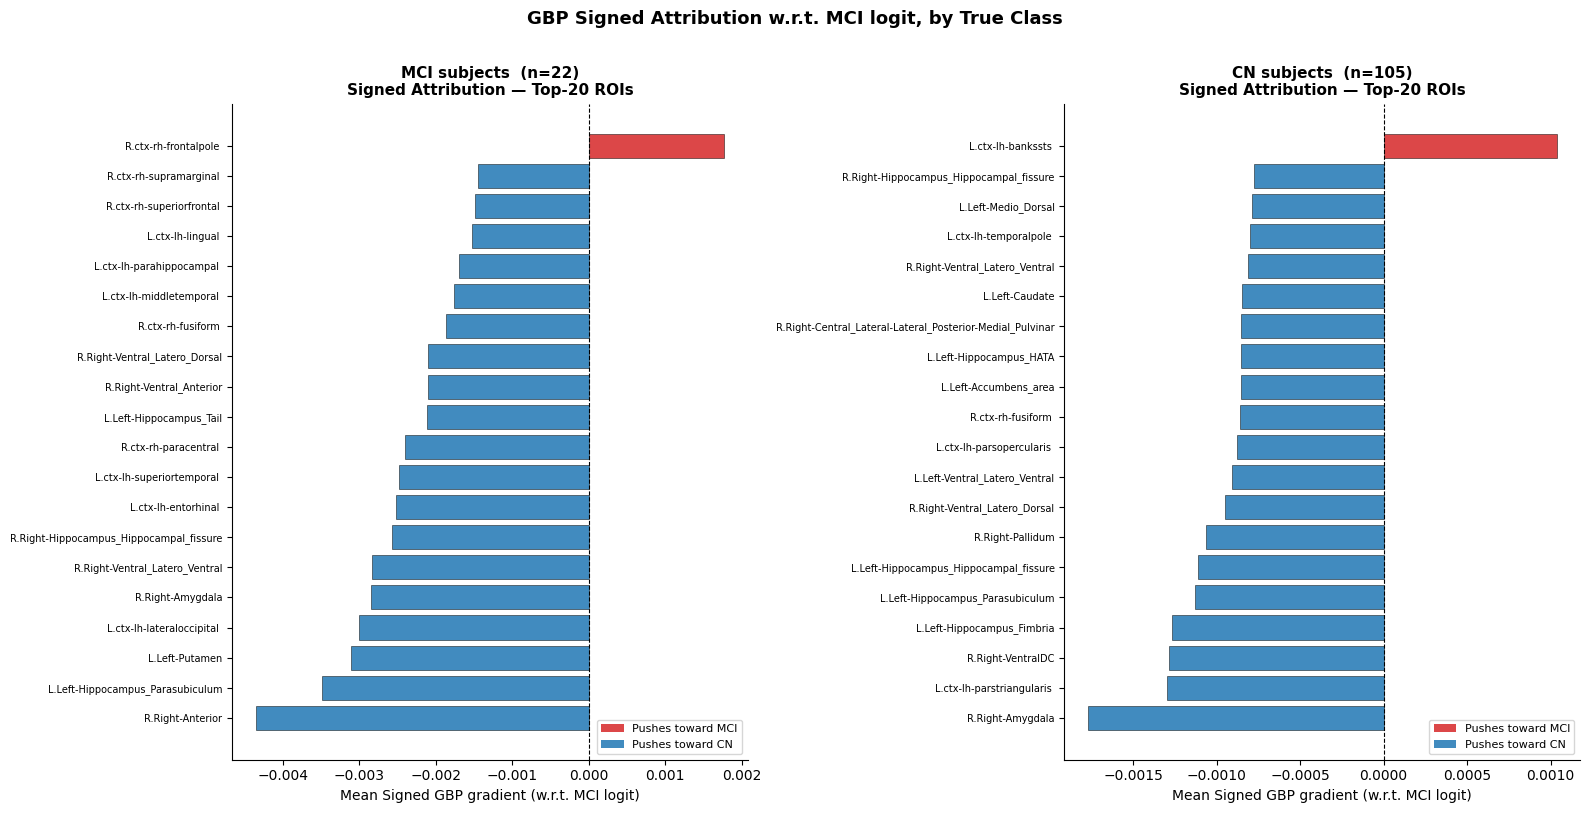

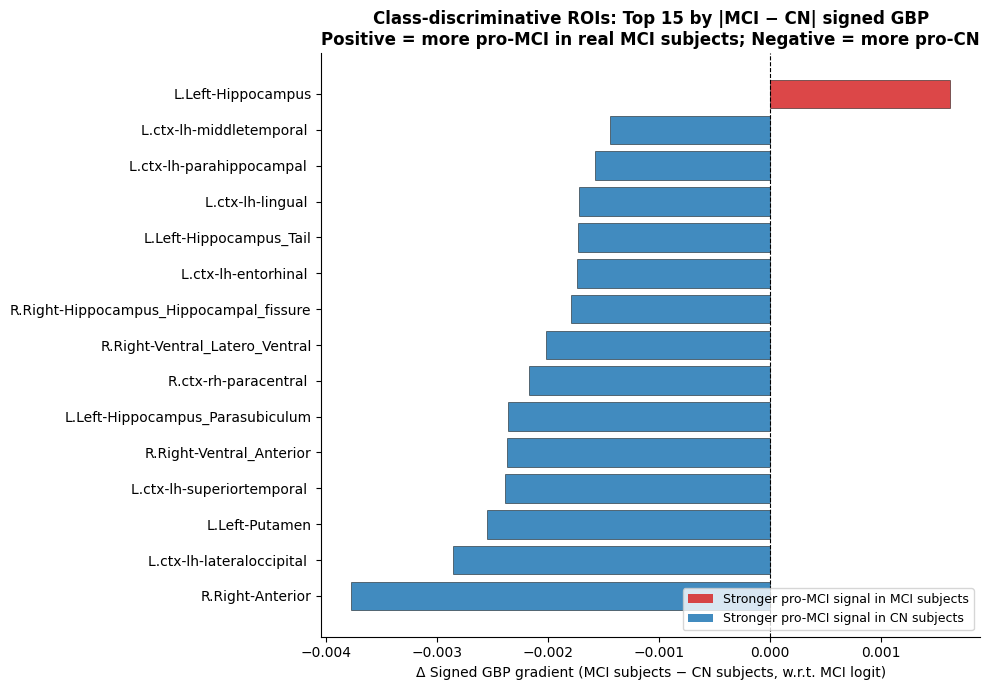

Top 15 class-discriminative ROIs (|MCI − CN| signed GBP):
   1. L.Left-Hippocampus                             Δ=+0.001626  (pro-MCI in MCI)
   2. L.ctx-lh-middletemporal                        Δ=-0.001442  (pro-CN in MCI)
   3. L.ctx-lh-parahippocampal                       Δ=-0.001577  (pro-CN in MCI)
   4. L.ctx-lh-lingual                               Δ=-0.001720  (pro-CN in MCI)
   5. L.Left-Hippocampus_Tail                        Δ=-0.001727  (pro-CN in MCI)
   6. L.ctx-lh-entorhinal                            Δ=-0.001743  (pro-CN in MCI)
   7. R.Right-Hippocampus_Hippocampal_fissure        Δ=-0.001789  (pro-CN in MCI)
   8. R.Right-Ventral_Latero_Ventral                 Δ=-0.002017  (pro-CN in MCI)
   9. R.ctx-rh-paracentral                           Δ=-0.002176  (pro-CN in MCI)
  10. L.Left-Hippocampus_Parasubiculum               Δ=-0.002362  (pro-CN in MCI)
  11. R.Right-Ventral_Anterior                       Δ=-0.002374  (pro-CN in MCI)
  12. L.ctx-lh-superiortemporal        

In [19]:
MCI_POS_COLOR = '#d62728'
MCI_NEG_COLOR = '#1f77b4'

def plot_signed_class(ax, node_sgn, cls_name, n, top_n=TOP_N):
    top_idx    = np.argsort(np.abs(node_sgn))[::-1][:top_n]
    top_names  = [ROI_NAMES[i] for i in top_idx]
    top_vals   = node_sgn[top_idx]
    order      = np.argsort(top_vals)
    top_names  = [top_names[i] for i in order]
    top_vals   = top_vals[order]
    colors     = [MCI_POS_COLOR if v > 0 else MCI_NEG_COLOR for v in top_vals]
    ax.barh(top_names, top_vals, color=colors, alpha=0.85,
            edgecolor='black', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Mean Signed GBP gradient (w.r.t. MCI logit)', fontsize=10)
    ax.set_title(f'{cls_name}  (n={n})\nSigned Attribution — Top-{top_n} ROIs',
                 fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='y', labelsize=7)
    legend_elements = [
        Patch(facecolor=MCI_POS_COLOR, alpha=0.85, label='Pushes toward MCI'),
        Patch(facecolor=MCI_NEG_COLOR, alpha=0.85, label='Pushes toward CN'),
    ]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')


# --- Panel 1: signed attribution per class (MCI and CN side by side) ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
plot_signed_class(axes[0], cls_node_sgn_avg[1], 'MCI subjects', cls_count[1])
plot_signed_class(axes[1], cls_node_sgn_avg[0], 'CN subjects',  cls_count[0])
plt.suptitle('GBP Signed Attribution w.r.t. MCI logit, by True Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_signed_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Panel 2: class-discriminative ROIs (MCI − CN signed difference) ----------
diff     = cls_node_sgn_avg[1] - cls_node_sgn_avg[0]
top_idx  = np.argsort(np.abs(diff))[::-1][:15]
top_names = [ROI_NAMES[i] for i in top_idx]
top_diff  = diff[top_idx]
order     = np.argsort(top_diff)
top_names = [top_names[i] for i in order]
top_diff  = top_diff[order]
colors    = [MCI_POS_COLOR if d > 0 else MCI_NEG_COLOR for d in top_diff]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_names, top_diff, color=colors, alpha=0.85, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Δ Signed GBP gradient (MCI subjects − CN subjects, w.r.t. MCI logit)', fontsize=10)
ax.set_title('Class-discriminative ROIs: Top 15 by |MCI − CN| signed GBP\n'
             'Positive = more pro-MCI in real MCI subjects; Negative = more pro-CN',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
legend_elements = [
    Patch(facecolor=MCI_POS_COLOR, alpha=0.85, label='Stronger pro-MCI signal in MCI subjects'),
    Patch(facecolor=MCI_NEG_COLOR, alpha=0.85, label='Stronger pro-MCI signal in CN subjects'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_class_discriminative_rois.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 class-discriminative ROIs (|MCI − CN| signed GBP):')
for i, (name, d) in enumerate(zip(top_names[::-1], top_diff[::-1]), 1):
    direction = 'pro-MCI in MCI' if d > 0 else 'pro-CN in MCI'
    print(f'  {i:2d}. {name:<45s}  Δ={d:+.6f}  ({direction})')


### Section 11 — Top-20 Connections: MCI vs CN (true label split)

Which structural connectivity pathways matter most for MCI subjects vs CN subjects?

Each panel ranks the top-20 pairs of ROIs by mean `|GBP gradient|` w.r.t. the MCI logit.
Both use the same attribution target so the edge weights are on the same scale.

ROI pairs that appear in the MCI list but not the CN list are MCI-specific connectivity
signatures; pairs in both lists are non-discriminative (model attends to them regardless).

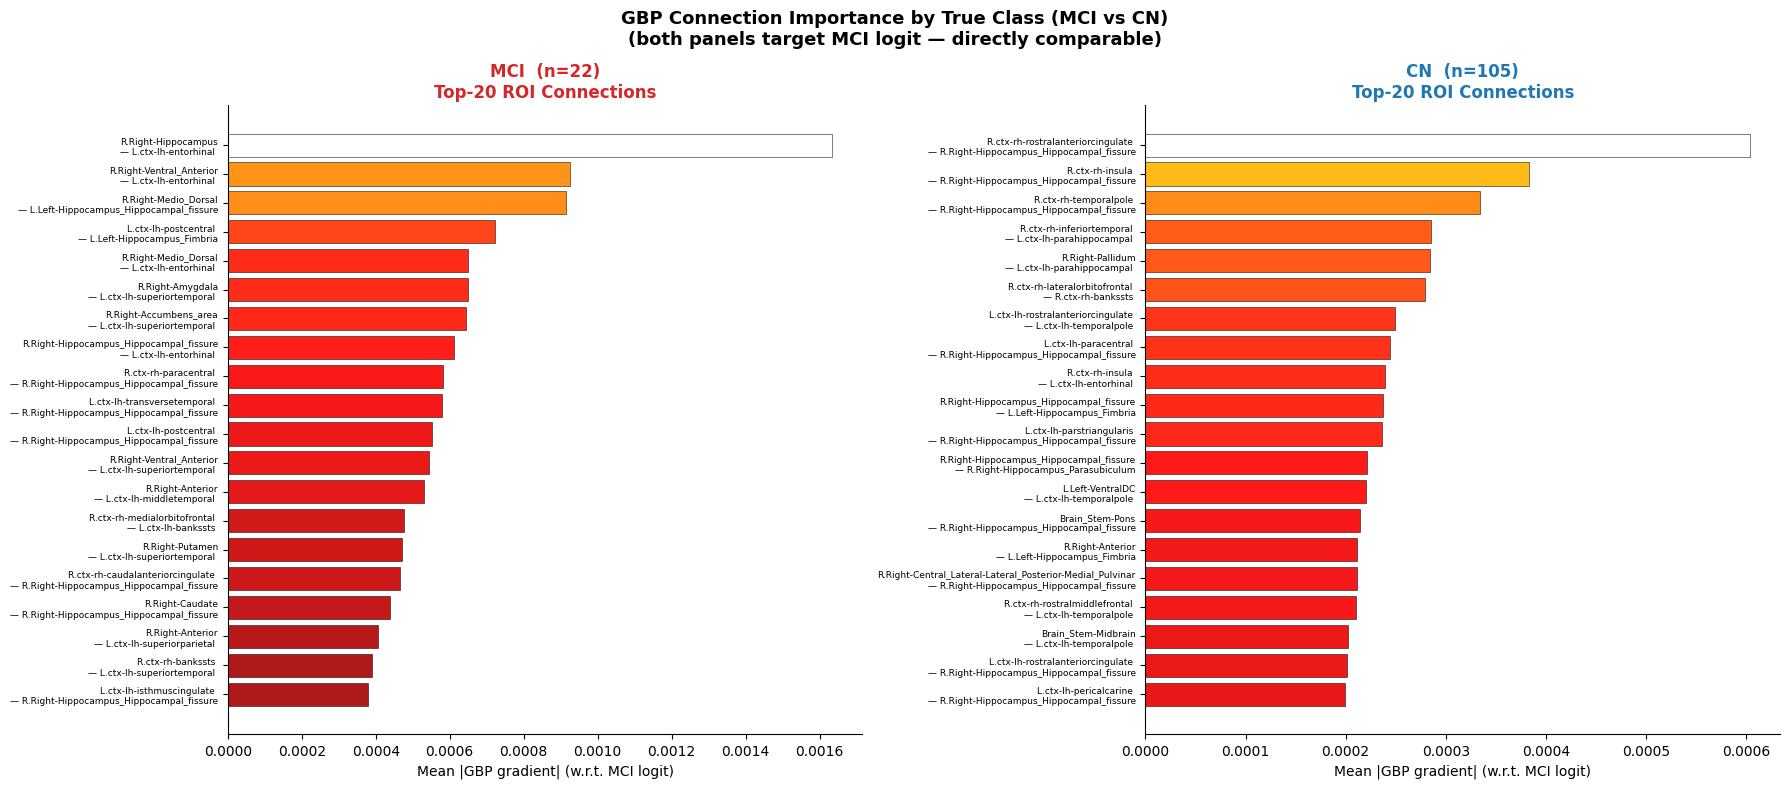

Top-20 connection overlap: 0 shared, 20 MCI-only, 20 CN-only

MCI-specific connections (top-20 for MCI, not for CN):
  R.Right-Hippocampus                      — L.ctx-lh-entorhinal                       MCI=0.001634  CN=0.000147
  R.Right-Ventral_Anterior                 — L.ctx-lh-entorhinal                       MCI=0.000926  CN=0.000006
  R.Right-Medio_Dorsal                     — L.Left-Hippocampus_Hippocampal_fissure    MCI=0.000915  CN=0.000013
  L.ctx-lh-postcentral                     — L.Left-Hippocampus_Fimbria                MCI=0.000721  CN=0.000007
  R.Right-Medio_Dorsal                     — L.ctx-lh-entorhinal                       MCI=0.000649  CN=0.000005
  R.Right-Amygdala                         — L.ctx-lh-superiortemporal                 MCI=0.000649  CN=0.000020
  R.Right-Accumbens_area                   — L.ctx-lh-superiortemporal                 MCI=0.000644  CN=0.000008
  R.Right-Hippocampus_Hippocampal_fissure  — L.ctx-lh-entorhinal                       MCI=0

In [20]:
K_conn = 20

def top_k_connections(mat, k):
    mask = np.triu(mat, k=1)
    f    = np.argsort(mask.ravel())[::-1]
    r, c = np.unravel_index(f[:k], (NUM_NODES, NUM_NODES))
    return r, c


fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, cls_idx in zip(axes, [1, 0]):   # MCI first, CN second
    cls_name = CLASS_NAMES[cls_idx]
    color    = CLASS_COLORS[cls_idx]
    mat      = cls_conn_avg[cls_idx]
    n        = cls_count[cls_idx]
    tr, tc   = top_k_connections(mat, K_conn)
    labels   = [f'{ROI_NAMES[r]}\n— {ROI_NAMES[c]}' for r, c in zip(tr, tc)]
    vals     = [mat[r, c] for r, c in zip(tr, tc)]
    bar_c    = plt.cm.hot(np.array(vals) / max(vals))
    ax.barh(range(K_conn)[::-1], vals, color=bar_c, alpha=0.9,
            edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(K_conn)[::-1])
    ax.set_yticklabels(labels, fontsize=6.5)
    ax.set_xlabel('Mean |GBP gradient| (w.r.t. MCI logit)', fontsize=10)
    ax.set_title(f'{cls_name}  (n={n})\nTop-{K_conn} ROI Connections',
                 fontsize=12, fontweight='bold', color=color)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GBP Connection Importance by True Class (MCI vs CN)\n'
             '(both panels target MCI logit — directly comparable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_connection_by_class.png'), dpi=150, bbox_inches='tight')
plt.show()

# Overlap analysis
mci_conns = set(zip(*[x.tolist() for x in top_k_connections(cls_conn_avg[1], K_conn)]))
cn_conns  = set(zip(*[x.tolist() for x in top_k_connections(cls_conn_avg[0], K_conn)]))
shared    = mci_conns & cn_conns

print(f'Top-{K_conn} connection overlap: {len(shared)} shared, '
      f'{len(mci_conns - cn_conns)} MCI-only, {len(cn_conns - mci_conns)} CN-only\n')

print(f'MCI-specific connections (top-{K_conn} for MCI, not for CN):')
for r, c in sorted(mci_conns - cn_conns, key=lambda x: -cls_conn_avg[1][x]):
    print(f'  {ROI_NAMES[r]:<40s} — {ROI_NAMES[c]:<40s}  MCI={cls_conn_avg[1][r,c]:.6f}  CN={cls_conn_avg[0][r,c]:.6f}')

print(f'\nCN-specific connections (top-{K_conn} for CN, not for MCI):')
for r, c in sorted(cn_conns - mci_conns, key=lambda x: -cls_conn_avg[0][x]):
    print(f'  {ROI_NAMES[r]:<40s} — {ROI_NAMES[c]:<40s}  CN={cls_conn_avg[0][r,c]:.6f}  MCI={cls_conn_avg[1][r,c]:.6f}')


### Section 12 — Signed ROI Importance: Which Feature, Which Direction?

This section answers: **did a *smaller* or *larger* hippocampus (or other top ROI) drive the MCI prediction?**

For each of the top-10 most important ROIs, we show the signed GBP gradient **per feature**
(volume, thickness, has_volume, has_thickness), averaged over MCI subjects and CN subjects separately.

**How to read:**
- `volume` bar **positive** → larger volume → more MCI signal. So a *smaller* volume (negative) would push *away* from MCI.
  In other words, if you see a **negative** volume gradient in MCI subjects, it means *smaller hippocampus → more MCI* (the expected clinical finding).
- `thickness` bar **negative** → cortical thinning pushes toward MCI (i.e., thicker cortex = less MCI).
- The `has_volume` / `has_thickness` features are binary missingness indicators — their sign reveals whether *data availability* itself is informative (a data-quality confound to be aware of).

The difference heatmap (MCI − CN) shows which features and ROIs shift the most between populations.

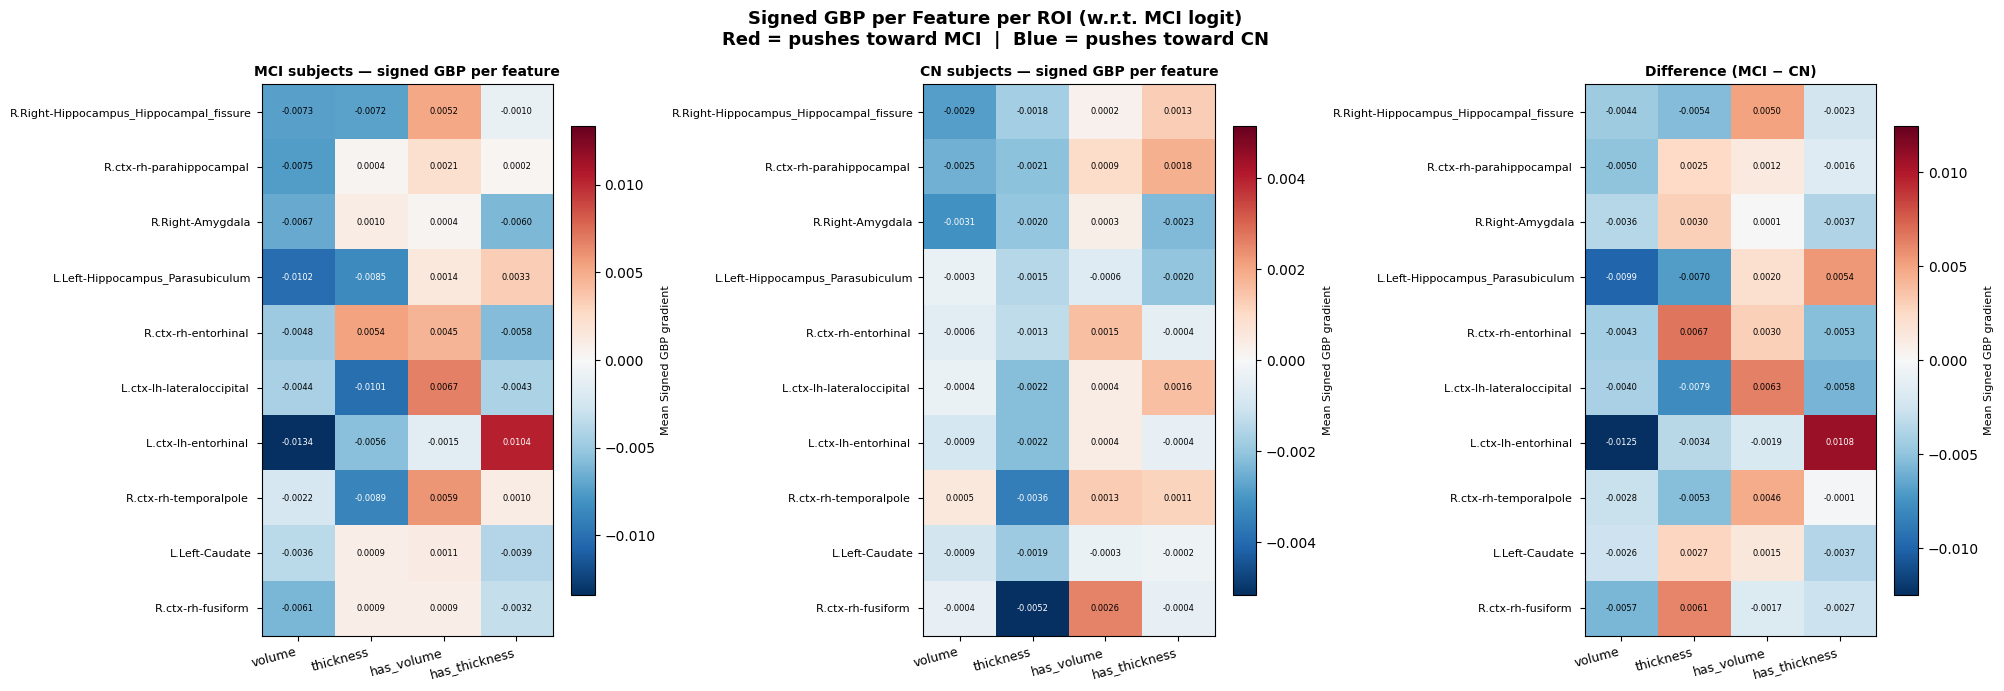

Directional interpretation for top ROIs:

ROI                                              MCI vol     CN vol   MCI thick    CN thick  Interpretation
--------------------------------------------------------------------------------------------------------------
R.Right-Hippocampus_Hippocampal_fissure         -0.00726   -0.00285    -0.00719    -0.00177  vol:smaller→MCI, thick:thinner→MCI
R.ctx-rh-parahippocampal                        -0.00747   -0.00248    +0.00038    -0.00213  vol:smaller→MCI, thick:thicker→MCI
R.Right-Amygdala                                -0.00669   -0.00311    +0.00098    -0.00199  vol:smaller→MCI, thick:thicker→MCI
L.Left-Hippocampus_Parasubiculum                -0.01020   -0.00035    -0.00847    -0.00148  vol:smaller→MCI, thick:thinner→MCI
R.ctx-rh-entorhinal                             -0.00483   -0.00058    +0.00535    -0.00133  vol:smaller→MCI, thick:thicker→MCI
L.ctx-lh-lateraloccipital                       -0.00439   -0.00035    -0.01006    -0.00218  vol:sm

In [21]:
TOP_ROI_N = 10

# Select top ROIs by combined importance (mean of MCI and CN absolute scores)
combined_abs = 0.5 * (cls_node_abs_avg[1] + cls_node_abs_avg[0])
top_roi_idx  = np.argsort(combined_abs)[::-1][:TOP_ROI_N]
top_roi_names = [ROI_NAMES[i] for i in top_roi_idx]

# cls_feat_sgn_avg[c] is (NUM_NODES, 4): signed gradient per node per feature, averaged over subjects
mci_feat = cls_feat_sgn_avg[1][top_roi_idx]   # (TOP_ROI_N, 4)
cn_feat  = cls_feat_sgn_avg[0][top_roi_idx]   # (TOP_ROI_N, 4)
diff_feat = mci_feat - cn_feat                 # (TOP_ROI_N, 4)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, data, title, cmap in [
    (axes[0], mci_feat,  'MCI subjects — signed GBP per feature', 'RdBu_r'),
    (axes[1], cn_feat,   'CN subjects — signed GBP per feature',  'RdBu_r'),
    (axes[2], diff_feat, 'Difference (MCI − CN)',                  'RdBu_r'),
]:
    vmax = np.abs(data).max()
    im   = ax.imshow(data, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85).set_label('Mean Signed GBP gradient', fontsize=8)
    ax.set_xticks(range(NODE_IN))
    ax.set_xticklabels(NODE_FEAT_NAMES, fontsize=9, rotation=15, ha='right')
    ax.set_yticks(range(TOP_ROI_N))
    ax.set_yticklabels(top_roi_names, fontsize=8)
    ax.set_title(title, fontsize=10, fontweight='bold')
    for i in range(TOP_ROI_N):
        for j in range(NODE_IN):
            v = data[i, j]
            ax.text(j, i, f'{v:.4f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(v) > vmax * 0.6 else 'black')

plt.suptitle('Signed GBP per Feature per ROI (w.r.t. MCI logit)\n'
             'Red = pushes toward MCI  |  Blue = pushes toward CN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gbp_signed_feature_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# Textual interpretation for volume and thickness
print('Directional interpretation for top ROIs:\n')
print(f'{"ROI":<45s}  {"MCI vol":>9s}  {"CN vol":>9s}  {"MCI thick":>10s}  {"CN thick":>10s}  Interpretation')
print('-' * 110)
for k, roi_i in enumerate(top_roi_idx):
    name      = ROI_NAMES[roi_i]
    mv, cv    = cls_feat_sgn_avg[1][roi_i, 0], cls_feat_sgn_avg[0][roi_i, 0]
    mt, ct    = cls_feat_sgn_avg[1][roi_i, 1], cls_feat_sgn_avg[0][roi_i, 1]
    vol_dir   = 'larger→MCI' if mv > 0 else 'smaller→MCI'
    thick_dir = 'thicker→MCI' if mt > 0 else 'thinner→MCI'
    print(f'{name:<45s}  {mv:>+9.5f}  {cv:>+9.5f}  {mt:>+10.5f}  {ct:>+10.5f}  vol:{vol_dir}, thick:{thick_dir}')
